# The multi-line transformer against classical and pooled neural benchmarks

One question drives this notebook: **does a neural model that attends across a company's
lines of business improve forecasts and aggregate uncertainty over both classical
multivariate models and neural models that merely pool training data?** The gallery has
carried a model built to ask it - `nn_transformer_ml`, whose encoder runs self-attention
over every cell of every line a company writes - since July, but notebook 3b had to leave
it out: on 3b's panel its rollout ran past ten minutes and was abandoned. This notebook
runs it, times it, and reports the times rather than capping them.

The comparison runs on a new, larger panel. Notebook 3b used the classic Meyers window,
accident years 1990-1997 with a 1998 holdout. This notebook uses the accident years
1998-2007 that the CAS published in March 2026, valued at 31 December 2007, with the
development realized in calendar year 2008 as the held-out diagonal and the later
statements through 2016 as the outcome record. The company selection mirrors the
companion R implementation's rule (`transformers_reserving/Code/data_prep.R`),
re-derived here from the same gold mart every other data call uses - no CSV downloads.
It passes 91 companies and 243 company-line cohorts across all six Schedule P lines,
roughly ten times notebook 3b's panel.

The comparison has three parts:

* the four single-line neural entries - `nn_transformer`, `mdn`, `resnet` and
  `deeptriangle` - against Mack's distribution-free chain ladder on the next calendar
  diagonal, scored by the continuous ranked probability score (CRPS), by
  premium-normalized point error, and by the probability integral transform (PIT) of the
  realized outcomes;
* the same methods at the 120-month grid endpoint, joined there by Zhang's
  seemingly-unrelated-regressions multivariate chain ladder (`sur`) and by
  `nn_transformer_ml` in both of its cross-line dependence modes;
* and the company-total comparison the opening question needs: summed independent lines
  against `sur`'s joint draws against the multi-line transformer's, with each model's
  implied cross-line correlation beside its accuracy.

Each model is reached through the same sequence of calls:

```
gallery.fit(name, triangle, ...)          # a fitted GalleryEntry
  -> entry.log_lik_at(cells, field=...)   # ScoresHeldout  -> (draws, cells) log densities
  -> entry.predict_at(cells, field=...)   # PredictsHeldout -> (draws, cells) loss draws
  -> gallery.align_panel(...)             # one identical cell set per score
  -> gallery.leaderboard(panel)           # the board
```

## Reproducibility

The notebook runs from any working directory: every number below comes from a live fit,
and every path is resolved by the library from its own cache.

Requirements are Python 3.11 or 3.12 and
`pip install "ibnr[nn]==0.5.6" cas-schedule-p==2026.6.13 matplotlib`. Both versions are
pinned and asserted in the cells that follow: the multi-line section reads internals of
ibnr 0.5.6, and the `cas-schedule-p` package names the data publish every result below
is asserted against. The triangle source is pinned to gold publish `20260613_041006`.

Installing is the only step that needs the network. The `cas-schedule-p` wheel carries
the whole gold publish, and the seeding cell below copies it into the directory ibnr's
loader reads, so the data load itself is offline. Without the seeding cell - the
ordinary case for a user of the library - ibnr fetches the release assets from the
public data repository over plain HTTPS. Runtime is dominated by the model fits; every
fit is timed where it runs and the closing cell totals them.

In [1]:
# %pip install "ibnr[nn]==0.5.6" cas-schedule-p==2026.6.13 matplotlib

import datetime as dt
import platform
import sys
import time
import warnings

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, display

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery import (
    SCORE_DIRECTION,
    Absence,
    CohortForecast,
    align_panel,
    next_diagonal,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels.calibration import ks_uniformity, pp_points

# What the version pin carries. The multi-line section below reads modules that are not
# public API - the company data contract, the network class - as they stand in this
# exact release. The panel assert further down pins a data publish.
assert ibnr.__version__ == "0.5.6", (
    f"this notebook is pinned to ibnr 0.5.6 and found {ibnr.__version__}. "
    'Install the exact version:  pip install "ibnr[nn]==0.5.6" '
    "cas-schedule-p==2026.6.13 matplotlib"
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

T_START = time.perf_counter()  # the wall clock the closing cell reports

# --- the one cutoff, the one field ------------------------------------------
AS_OF = dt.date(2007, 12, 31)
FIELD = "paid_loss"
TASK = f"{FIELD}@2007"
PREMIUM_FIELD = "earned_premium"
# THE STUDY WINDOW. The triangle itself is cut to these accident years before
# anything is fitted, so every fit and every held-out cell rest on the same
# data. Accident years 1988-1997 - the classic Meyers window notebook 3b ran
# on - are out of this study entirely; they are not merely left unscored.
ORIGINS = [dt.date(y, 1, 1) for y in range(1998, 2008)]
SEED_FIT = 11  # every torch init
SEED_DRAW = 7  # every predict_at() and predict() call

print("ibnr  ", ibnr.__version__)
print("python", sys.version.split()[0], platform.platform())

ibnr   0.5.6
python 3.12.13 Windows-11-10.0.26200-SP0


## Data source

The panel is built from a CAS Schedule P gold mart, which the package consumes as an
immutable GitHub release: one release per gold publish, tagged with its publish id and
carrying a manifest of sha256 sums. This is the "pull from the GitHub repo" path: the
mart is the single data source, where the companion R implementation downloads the six
CAS csv files directly from casact.org on every run. Both trace back to the same March
2026 CAS release; the mart adds the publish pin, the checksums and the cache.

The loader caches the release under `~/.cache/ibnr` (or `IBNR_CACHE_DIR` if it is set)
and reads a pinned tag from disk. The seeding cell below fills that cache from the
`cas-schedule-p` wheel, which carries this publish.

The tag is a concrete publish id rather than a floating pointer, for two reasons. A
floating tag has to be resolved against the GitHub API on every run, even when the data
are already cached; and the panel assertion below is a claim about one specific publish.
`active_publish_id` re-reads the cached manifest. Every data call below is handed the
same pinned string.

In [2]:
# --- seed ibnr's download cache from the installed data package --------------
# The cas-schedule-p wheel already carries this gold publish - sixteen parquet tables plus
# manifest.json - so copying those files where ibnr's loader looks turns every data call
# below into a local file read. Skip this cell and the loader downloads the same files
# over anonymous HTTPS instead.
#
# The layout is ibnr's own, read off ibnr/data/schedule_p.py:_cache_dir - IBNR_CACHE_DIR
# (or ~/.cache/ibnr) / "<owner>__<repo>" / "<publish_id>" - and manifest.json is the file
# it tests for a warm cache. The publish seeded is the wheel's own; the next cell pins the
# same string in SOURCE, and the selection cell asserts that the two agree.
import os
import shutil
from pathlib import Path

import cas_schedule_p

_cache_root = os.environ.get("IBNR_CACHE_DIR")
CACHE_DIR = (
    (Path(_cache_root) if _cache_root else Path.home() / ".cache" / "ibnr")
    / cas_schedule_p.REPO.replace("/", "__")
    / cas_schedule_p.PUBLISH_ID
)

if (CACHE_DIR / "manifest.json").exists():
    print(f"cache already holds publish {cas_schedule_p.PUBLISH_ID}: {CACHE_DIR}")
else:
    _entries = cas_schedule_p.manifest()["tables"]
    _bundled = [cas_schedule_p.path(t) for t in cas_schedule_p.tables()]
    # manifest.json sits beside the parquet files and is copied LAST, so an interrupted
    # seed cannot leave a cache that reads as complete; each file lands under a temp name
    # and is renamed into place for the same reason.
    _bundled.append(_bundled[0].parent / "manifest.json")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for _src in _bundled:
        _dest = CACHE_DIR / _src.name
        _tmp = _dest.with_name(_dest.name + ".part")
        shutil.copyfile(_src, _tmp)
        os.replace(_tmp, _dest)
    # the size test the loader itself applies to an already-cached asset
    assert all((CACHE_DIR / e["asset"]).stat().st_size == e["bytes"] for e in _entries.values())
    print(f"seeded {len(_bundled)} files into {CACHE_DIR}")

cache already holds publish 20260613_041006: C:\Users\EthanKang\.cache\ibnr\EKtheSage__cas-schedule-p-data-model\20260613_041006


In [3]:
# --- provenance -------------------------------------------------------------
SOURCE = pinned_source("github://EKtheSage/cas-schedule-p-data-model@20260613_041006")
PUBLISH_ID = active_publish_id(SOURCE)
assert PUBLISH_ID == "20260613_041006", PUBLISH_ID

MART = active_mart_path(SOURCE)
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", MART.name)

assert cas_schedule_p.__version__ == "2026.6.13", (
    f"this notebook is pinned to cas-schedule-p 2026.6.13 and found {cas_schedule_p.__version__}"
)
# The wheel that seeded the cache and the mart being read must be the SAME gold publish.
assert cas_schedule_p.PUBLISH_ID == PUBLISH_ID, (cas_schedule_p.PUBLISH_ID, PUBLISH_ID)

mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet


## Data and panel selection

The panel is chosen by a fixed, mechanical selection rule deciding which companies
enter the study. The same rule runs for every model, so a difference on a board comes from the
models and never from which companies each was allowed to see.

The selection rule is the companion R implementation's
(`transformers_reserving/Code/data_prep.R`, `build_multiline_reserving_dataset`),
re-derived from the mart so the two projects study the same companies and years. Its
criteria, clause by clause:

1. **The study years.** Accident years 1998 through 2007 - the vintage the CAS published
   in March 2026, which this mart ingests alongside the classic 1988-1997 files.
2. **All-positive cumulative paid.** A (company, line, accident year) row is kept only
   if every one of its ten statements reports cumulative paid loss above zero. This is
   the R code's `all(cum_paid > 0)` filter, and it is also exactly `sur`'s own
   requirement, whose whitening step divides by the square root of each cumulative.
   Note what it does not require: paid increments may still be negative.
3. **A complete square.** A (company, line) pair survives only with all ten accident
   years intact after clause 2 - one hundred cells, a full 10x10 triangle.
4. **Multi-line participation.** A company enters only with at least two surviving
   lines, because a cross-line question needs companies with lines to cross.

One condition is added here that the R code applies later and implicitly: **net earned
premium must be positive in every accident year of the window.** The R code drops
individual training rows with non-positive premium when it builds samples; a triangle
model cannot drop a row without dropping the cohort, and every neural entry here
conditions on log premium. The cell below names the cohorts this costs.

The selection runs over the same cached parquet every other data call uses, so the whole
notebook stays on one file. It is defined in this notebook rather than imported: the data
package already ships the Meyers company criteria for the classic window as one
versioned artifact - constants, SQL and mart in one release - and this selection rule
should graduate there the same way once the paper's panel definition settles. Until then the pinned publish
id and the panel fingerprint below are the reproducibility anchors.

This is a retrospective benchmark panel. Requiring a complete all-positive square uses
later knowledge that the full rows exist, and multiline participation narrows the
population further. The task evaluates future development for these existing insurers;
it does not measure generalization to unseen companies.

In [4]:
# The 3c selection rule: transformers_reserving/Code/data_prep.R, clause by clause, over the
# pinned mart. duckdb reads the same parquet file the ibnr loader will read below.
import hashlib

import duckdb

t0 = time.perf_counter()
_con = duckdb.connect()
_t = f"read_parquet('{MART.as_posix()}')"
_pairs = _con.execute(f"""
with cells as (                    -- clause 1: the study years
  select company_code, line_of_business, accident_year, cum_paid_loss, earned_prem_net
  from {_t} where accident_year between 1998 and 2007
),
ay_ok as (                         -- clause 2: all ten statements present, all cum paid > 0
  select company_code, line_of_business, accident_year, min(earned_prem_net) as prem
  from cells group by 1, 2, 3
  having count(*) = 10 and min(cum_paid_loss) > 0
),
pair_ok as (                       -- clause 3: all ten accident years survive
  select company_code, line_of_business, min(prem) as min_prem
  from ay_ok group by 1, 2 having count(*) = 10
)
select company_code, line_of_business, min_prem from pair_ok
order by company_code, line_of_business
""").df()

# clause 4 on the R criteria alone, for the record
_multi_r = _pairs.groupby("company_code").size()
_r_panel = _pairs[_pairs["company_code"].isin(_multi_r[_multi_r > 1].index)]
print(
    f"R selection rule alone: {_r_panel['company_code'].nunique()} companies, "
    f"{len(_r_panel)} cohorts"
)

# the added premium condition, with its cost named
_bad_prem = _r_panel[_r_panel["min_prem"] <= 0]
print(f"cohorts with a non-positive net premium accident year: {len(_bad_prem)}")
for _, _r in _bad_prem.iterrows():
    print(f"   dropped: {_r['company_code']} {_r['line_of_business']} (min premium {_r['min_prem']:.0f})")

_ok = _pairs[_pairs["min_prem"] > 0]
_multi = _ok.groupby("company_code").size()
_panel_pairs = _ok[_ok["company_code"].isin(_multi[_multi > 1].index)]
_knock_on = set(map(tuple, _r_panel[["company_code", "line_of_business"]].values)) - set(
    map(tuple, _panel_pairs[["company_code", "line_of_business"]].values)
) - set(map(tuple, _bad_prem[["company_code", "line_of_business"]].values))
for _c, _ln in sorted(_knock_on):
    print(f"   knock-on: {_c} {_ln} (its company fell below two qualifying lines)")

PANEL = {c: sorted(g["line_of_business"]) for c, g in _panel_pairs.groupby("company_code")}
COHORTS = [(c, ln) for c, ls in PANEL.items() for ln in ls]
LINES = sorted({ln for ls in PANEL.values() for ln in ls})
print(f"selection took {time.perf_counter() - t0:.1f}s")
print(f"\n{len(PANEL)} companies, {len(COHORTS)} cohorts, {len(LINES)} lines")
display(_panel_pairs.groupby("line_of_business").size().rename("cohorts").to_frame())

# Recorded: if a future gold publish moves the panel, these asserts catch it before the
# comparison runs. A 91-company dict is too long to embed the way notebook 3b embeds its
# ten, so the lock is the cohort-list fingerprint plus the counts.
PANEL_FINGERPRINT = hashlib.sha256(repr(sorted(COHORTS)).encode()).hexdigest()[:16]
assert (len(PANEL), len(COHORTS)) == (91, 243), (len(PANEL), len(COHORTS))
assert PANEL_FINGERPRINT == "9e184f4312247622", PANEL_FINGERPRINT
print("panel fingerprint", PANEL_FINGERPRINT)

_lines_per_company = pd.Series({c: len(ls) for c, ls in PANEL.items()})
print("\nlines per company:", _lines_per_company.value_counts().sort_index().to_dict())

R selection rule alone: 92 companies, 247 cohorts
cohorts with a non-positive net premium accident year: 3
   dropped: 10859 workers_compensation (min premium 0)
   dropped: 2143 products_liability (min premium -2)
   dropped: 38300 workers_compensation (min premium -1)
   knock-on: 10859 commercial_auto (its company fell below two qualifying lines)
selection took 0.1s

91 companies, 243 cohorts, 6 lines


,cohorts
line_of_business,
commercial_auto,79
medical_malpractice,1
other_liability,63
private_passenger_auto,60
products_liability,7
workers_compensation,33


panel fingerprint 9e184f4312247622

lines per company: {2: 48, 3: 28, 4: 12, 5: 3}


### The study window

The mart carries accident years 1988-2007; the study window is 1998-2007. The
restriction is applied once, to the triangle itself: `tri` holds only the study years,
and everything downstream - every fit, every call to `next_diagonal`, every realized
ultimate - reads `tri`. A single restricted table is what guarantees the fits and the
held-out census agree on what the training data were.

Unlike notebook 3b's window, this one is the full depth of its vintage: ten accident
years at the cutoff, so the training triangle is a complete 10x10 upper triangle and
the grid edge sits at 120 months of development. The realized record runs to statement
year 2016, deep enough to score every accident year at that edge.

In [5]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=list(PANEL), lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep only the
# 243 selected pairs.
_e = tri_all.expr
_keep = ibis.literal(False)
for c, ls in PANEL.items():
    for ln in ls:
        _keep = _keep | ((_e.company_code == c) & (_e.line_of_business == ln))
tri_full = tri_all.filter(_keep)

# The mart's display segment is dropped. The mart carries three segments; the neural
# data contracts treat company_name as display-only, so a pooled fit is keyed on two.
# Dropping the column here keeps every path on one schema.
tri_full = tri_full.with_expr(tri_full.expr.drop("company_name"))

tri = tri_full.filter(tri_full.expr.origin_period.isin(ORIGINS))
print("segments:", tri.segments)
print(f"{tri_full.count()} rows loaded in {time.perf_counter() - t0:.1f}s")
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)
print(
    f"{tri.count()} rows inside the study window: accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year} ({len(ORIGINS)} of them)"
)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_paid_latest = _frame[
    (_frame["field"] == FIELD) & (pd.to_datetime(_frame["eval_date"]) == pd.Timestamp(AS_OF))
]
# Total earned premium over the window, per cohort - the denominator the endpoint
# sections normalize reserve errors by, so books orders of magnitude apart in size are
# comparable. The mart books an origin's earned premium at every development age that
# origin carries, so summing the rows would count each origin's premium once per age.
# The premium is taken once per origin instead, and the assert is that the repeated
# rows agree.
_prem_by_origin = _prem.groupby(["company_code", "line_of_business", "origin_period"])["value"]
assert (_prem_by_origin.nunique() == 1).all()
PREMIUM_TOTAL = (
    _prem_by_origin.first().groupby(["company_code", "line_of_business"]).sum().to_dict()
)
pairs_table = (
    _prem.groupby(["company_code", "line_of_business"])["value"]
    .mean()
    .rename("mean_earned_premium")
    .to_frame()
    .join(
        _paid_latest.groupby(["company_code", "line_of_business"])["value"]
        .sum()
        .rename("paid_at_2007")
    )
    .reset_index()
    .sort_values("mean_earned_premium", ascending=False)
    .reset_index(drop=True)
)
print("\nunits:", tri.meta.units)
_share = pairs_table["mean_earned_premium"] / pairs_table["mean_earned_premium"].sum()
print(
    f"largest cohort mean premium {pairs_table['mean_earned_premium'].iloc[0]:,.0f}, "
    f"smallest {pairs_table['mean_earned_premium'].iloc[-1]:,.0f}; "
    f"top cohort carries {100 * _share.iloc[0]:.0f}% of panel premium"
)
pairs_table.head(15).round(0)

segments: ['company_code', 'line_of_business']


340200 rows loaded in 1.8s


170100 rows inside the study window: accident years 1998-2007 (10 of them)



units: USD thousands
largest cohort mean premium 16,002,308, smallest 42; top cohort carries 63% of panel premium


,company_code,line_of_business,mean_earned_premium,paid_at_2007
0,1767,private_passenger_auto,16002308.0,101400750.0
1,2003,private_passenger_auto,2714098.0,16768581.0
2,1767,other_liability,501172.0,2560824.0
3,4839,private_passenger_auto,453040.0,3186818.0
4,7080,private_passenger_auto,434988.0,2259932.0
5,1767,workers_compensation,306346.0,1049941.0
6,7080,workers_compensation,305126.0,1607836.0
7,1767,commercial_auto,282306.0,1511485.0
8,2135,workers_compensation,240267.0,1203318.0
9,1090,private_passenger_auto,233028.0,1679670.0


## Held-out cells

`next_diagonal(triangle, as_of=..., fields=...)` answers one question: given a fit
trained on everything visible at `as_of`, which cells is it scored on? The answer is the
next calendar diagonal, one cohort at a time, with the next development lag read from
the data. Cells the fit could not have known about are excluded and counted by reason
(`new_origin`, `dev_beyond_trained`, and so on).

Two choices are worth stating.

**Cells are built for both `paid_loss` and `reported_loss`, although the board is on
paid.** No entry on this board is scored on the second field - `deeptriangle` consumes
reported loss as its auxiliary training channel, which is an input rather than a score.
The second field is kept because the `HoldoutCells` objects are part of the panel's
identity: it contributes its own exclusion census, and building the cells this way keeps
the census shape comparable with notebook 3b's. So `n_cells` reads 18 per cohort while
the paid narrowing gives 9.

**There is no `origins=` argument, because the triangle is already the study window.**
`next_diagonal` accepts one, but it restricts the training claims the census is computed
from as well as the cells to be scored, so the returned `HoldoutCells` would describe a
training window narrower than the one the fits consumed. `HoldoutCells.train_origins`
is asserted below against `ORIGINS` for all 243 cohorts.

One difference from notebook 3b is worth naming. There, the oldest accident year's next
cell existed in the mart at an age deeper than the training window, so `next_diagonal`
excluded it by reason (`dev_beyond_trained`). Here the training window already reaches
120 months, the deepest age Schedule P reports, so the oldest accident year's next cell
does not exist in the data at all: nothing is offered and nothing needs excluding, and
every exclusion counter below reads zero.

That leaves 9 held-out paid cells per cohort, 2,187 offered in total. How many of them a
score rests on is decided later, by the intersection over that score's own members.

In [6]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for c, ln in COHORTS:
    s = tri.filter((tri.expr.company_code == c) & (tri.expr.line_of_business == ln))
    sub[(c, ln)] = s
    cells[(c, ln)] = next_diagonal(
        s,
        as_of=AS_OF,
        # both fields, matching notebook 3b's census shape
        fields=[FIELD, "reported_loss"],
        premium_field=PREMIUM_FIELD,
    )
print(f"{len(COHORTS)} x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[COHORTS[0]]
print(
    f"\n{COHORTS[0]}: n_cells={_one.n_cells} (both fields), "
    f"paid={(_one.frame['field'] == FIELD).sum()}"
)
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK. train_origins is what the held-out census believes the fit
# was trained on. It has to be the study window itself, on every cohort, or the
# board scores one training set and describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
print(
    "train_origins  ",
    f"{_one.train_origins[0]} .. {_one.train_origins[-1]}",
    f"(all {len(COHORTS)} cohorts)",
)

_counts = {k: int((v.frame["field"] == FIELD).sum()) for k, v in cells.items()}
print(
    "paid cells per cohort:", sorted(set(_counts.values())), "| panel total:", sum(_counts.values())
)
_one.frame[_one.frame["field"] == FIELD]

243 x next_diagonal in 621.5s

('10022', 'commercial_auto'): n_cells=18 (both fields), paid=9
as_of       2007-12-31
eval_date   2008-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 0, 'no_predecessor': 0}
train_origins   1998-01-01 .. 2007-01-01 (all 243 cohorts)
paid cells per cohort: [9] | panel total: 2187


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1999-01-01,120,2008-12-31,494.0,495.0,1726.0
1,10022,commercial_auto,paid_loss,2000-01-01,108,2008-12-31,794.0,794.0,1843.0
2,10022,commercial_auto,paid_loss,2001-01-01,96,2008-12-31,786.0,784.0,2009.0
3,10022,commercial_auto,paid_loss,2002-01-01,84,2008-12-31,730.0,714.0,2271.0
4,10022,commercial_auto,paid_loss,2003-01-01,72,2008-12-31,1225.0,1092.0,2419.0
5,10022,commercial_auto,paid_loss,2004-01-01,60,2008-12-31,876.0,847.0,2465.0
6,10022,commercial_auto,paid_loss,2005-01-01,48,2008-12-31,793.0,634.0,2266.0
7,10022,commercial_auto,paid_loss,2006-01-01,36,2008-12-31,800.0,397.0,2343.0
8,10022,commercial_auto,paid_loss,2007-01-01,24,2008-12-31,503.0,292.0,2312.0


### The upper triangle and the scored diagonal

One picture covers the whole panel, because every cohort has the same shape: the cell
below asserts that the accident years, the development ages, the scored locations and
the exclusions are identical across all 243 before it draws any of them. The dark blue
cells are the upper triangle - the cells observed at the cutoff, the training data of
every fit. The lighter cells are the final training diagonal, valued at 31 December
2007, drawn apart because they do a second job: the neural entries hold that diagonal
out of every training context and use it as the validation set for early stopping, which
is what validating by evaluation date means in practice. The orange cells one step below
are what the models are graded on, realized during calendar year 2008.

The oldest accident year has no orange cell. At the cutoff it already stands at 120
months, the deepest development age Schedule P reports, so no next cell for it exists in
the data - which is why nine cells are scored on a cohort with ten open accident years.

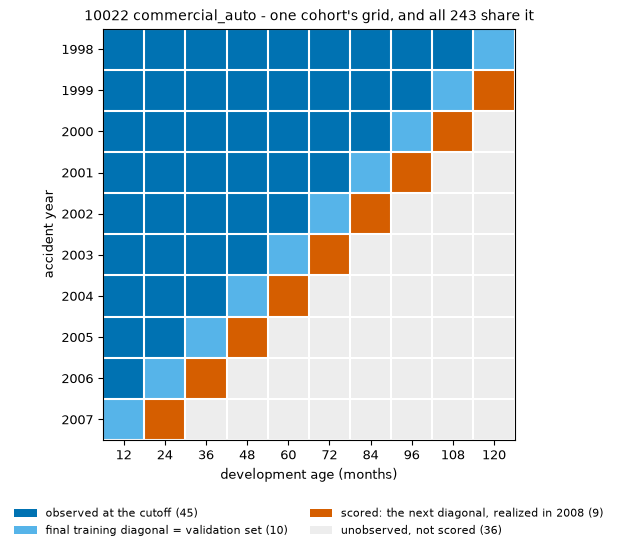

10 accident years x 10 development ages = 100 cells: 55 observed at 2007-12-31 (10 of them the final training diagonal), 9 scored, 36 unobserved.
no cells were excluded: the oldest accident year's next development age is beyond what Schedule P reports, so no cell for it exists to exclude.


In [7]:
# The picture, derived from the objects the board is built from: the training slice for
# the observed cells, the held-out census for the scored ones.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def _locations(frame):
    """(origin_period, dev_lag) pairs of a frame, as a hashable set."""
    return frozenset(
        zip(
            pd.to_datetime(frame["origin_period"]).dt.date,
            frame["dev_lag"].astype(int),
            strict=True,
        )
    )


_train = tri.as_of(AS_OF).expr.execute()
_train = _train[_train["field"] == FIELD]
_observed = {k: _locations(g) for k, g in _train.groupby(["company_code", "line_of_business"])}
_scored = {k: _locations(v.frame[v.frame["field"] == FIELD]) for k, v in cells.items()}
_beyond = {k: _locations(v.excluded[v.excluded["field"] == FIELD]) for k, v in cells.items()}
_why = {
    k: tuple(sorted(set(v.excluded.loc[v.excluded["field"] == FIELD, "reason"])))
    for k, v in cells.items()
}

# One grid speaks for the panel only if every cohort has that grid: same accident
# years, same development ages, same scored locations, same exclusions, on all
# 243 cohorts. The assert is what lets one figure stand for all of them.
assert len({(_observed[k], _scored[k], _beyond[k], _why[k]) for k in COHORTS}) == 1

_key = COHORTS[0]
_origins = sorted({o for o, _ in _observed[_key]})
_devs = sorted({d for _, d in _observed[_key] | _scored[_key]})
_oi = {o: i for i, o in enumerate(_origins)}
_di = {d: j for j, d in enumerate(_devs)}
# calendar index: cells sharing origin index + dev index share an evaluation date, so the
# largest one among the observed cells IS the final training diagonal
_cal = {(o, d): _oi[o] + _di[d] for o in _origins for d in _devs}
_last_train = max(_cal[c] for c in _observed[_key])

_TRAIN, _VALID, _SCORED, _FUTURE = 0, 1, 2, 3
_grid = np.full((len(_origins), len(_devs)), _FUTURE)
for _o, _d in _observed[_key]:
    _grid[_oi[_o], _di[_d]] = _VALID if _cal[(_o, _d)] == _last_train else _TRAIN
for _o, _d in _scored[_key]:
    _grid[_oi[_o], _di[_d]] = _SCORED

_colors = ["#0072B2", "#56B4E9", "#D55E00", "#EDEDED"]
_labels = [
    f"observed at the cutoff ({int((_grid == _TRAIN).sum())})",
    f"final training diagonal = validation set ({int((_grid == _VALID).sum())})",
    f"scored: the next diagonal, realized in 2008 ({int((_grid == _SCORED).sum())})",
    f"unobserved, not scored ({int((_grid == _FUTURE).sum())})",
]

fig, ax = plt.subplots(figsize=(7.0, 5.4), layout="constrained")
ax.imshow(_grid, cmap=ListedColormap(_colors), vmin=0, vmax=3)
ax.set_xticks(range(len(_devs)), [str(d) for d in _devs], fontsize=9)
ax.set_yticks(range(len(_origins)), [str(o.year) for o in _origins], fontsize=9)
ax.set_xticks(np.arange(-0.5, len(_devs)), minor=True)
ax.set_yticks(np.arange(-0.5, len(_origins)), minor=True)
ax.grid(which="minor", color="white", lw=1.5)
ax.tick_params(which="minor", length=0)
ax.set_xlabel("development age (months)", fontsize=9)
ax.set_ylabel("accident year", fontsize=9)
ax.set_title(f"{_key[0]} {_key[1]} - one cohort's grid, and all 243 share it", fontsize=10)
ax.legend(
    handles=[Patch(facecolor=c, label=t) for c, t in zip(_colors, _labels, strict=True)],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    fontsize=8,
    frameon=False,
)
plt.show()

print(
    f"{len(_origins)} accident years x {len(_devs)} development ages = {_grid.size} cells: "
    f"{int((_grid < _SCORED).sum())} observed at {AS_OF} "
    f"({int((_grid == _VALID).sum())} of them the final training diagonal), "
    f"{int((_grid == _SCORED).sum())} scored, {int((_grid == _FUTURE).sum())} unobserved."
)
_excluded = sorted((o.year, d) for o, d in _beyond[_key])
if _excluded:
    print(
        f"{len(_excluded)} further next-diagonal cell(s) fall beyond this grid, excluded as "
        f"{', '.join(_why[_key])}: "
        + ", ".join(f"accident year {y} at {d} months" for y, d in _excluded)
    )
else:
    print(
        "no cells were excluded: the oldest accident year's next development age is "
        "beyond what Schedule P reports, so no cell for it exists to exclude."
    )

## Entry capabilities

A forecast carries two independent capabilities, and the separation is what lets one
board hold entries of very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive density;
* `PredictsHeldout` -> `predict_at()` -> predictive draws, and hence CRPS.

The continuous ranked probability score (CRPS) generalizes absolute error to a
distributional forecast: it is the average absolute difference between a draw from the
forecast and the realized value, less half the average absolute difference between two
independent draws - the second term charging the forecast for its own spread, so neither
a wide hedge nor a false certainty scores well. For a point forecast it reduces to
absolute error; lower is better.

An entry may have either, both, or neither. `mack` draws from a bootstrap and states no
observation model, so it has draws and no density. Two entries in this study subclass
neither mixin and so have no held-out board row at all:

* `sur` states a joint model of a company's lines but implements no per-cell held-out
  hooks;
* `nn_transformer_ml` predicts and scores at the endpoint level through the ordinary
  gallery contract, but its held-out wiring is deliberately deferred in the source
  (`ibnr/gallery/nn/transformer_ml/model.py:54`): its cohort is a company, a
  next-diagonal cohort is a company-line pair, and bridging the two needs a multiline
  sibling of the `cohort_contract` adapter that the single-line entries share. Until
  that adapter exists, the entry joins the comparison where every entry produces a
  number - the 120-month endpoint and the company total - exactly as `sur` does.

That placement is a limitation of the two entries, not of the panel, and it is the
reason this notebook's central comparison happens at the endpoint level.

The roster below is built from the live registry. `config_class` is the same idea one
level down: it is how an entry names the dataclass its `fit(config=...)` takes.

In [8]:
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
                "config_class": getattr(cls.config_class, "__name__", "-"),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{(~roster['density'] & ~roster['draws (CRPS)']).sum()} neither"
)
# The entries this notebook uses, in the order they appear: the five on the held-out
# board, then the two that join at the endpoint level.
ON_THIS_BOARD = ["mack", "nn_transformer", "mdn", "resnet", "deeptriangle"]
ENDPOINT_ONLY = ["sur", "nn_transformer_ml"]
display(
    roster[roster["entry"].isin(ON_THIS_BOARD + ENDPOINT_ONLY)].reset_index(drop=True)
)

16 registered entries; 9 density, 13 draws, 3 neither


,entry,family,density,draws (CRPS),config_class
0,mack,deterministic,False,True,-
1,deeptriangle,nn,True,True,DeepTriangleConfig
2,mdn,nn,True,True,MDNConfig
3,nn_transformer,nn,True,True,TransformerConfig
4,nn_transformer_ml,nn,False,False,TransformerMLConfig
5,resnet,nn,True,True,ResNetConfig
6,sur,statistical,False,False,-


## Models and fitting

Every entry is fitted with exactly the arguments in the next cell. Nothing is tuned per
cohort.

`mack` is fitted separately on each cohort's triangle: 243 independent fits. Each
single-line neural entry is fitted once, on all 243 cohorts together, and that one fit
supplies every cohort's forecast. `nn_transformer_ml` is fitted once per dependence
mode, on all 91 companies together, each company's lines forming one joint training
example. Pooling is how these models are designed to be used - a single Schedule P
triangle carries 45 usable increments in this window, far too few to train a network -
but it means a neural forecast draws on the loss history of the whole panel while the
`mack` forecast beside it draws on one cohort. The limitations section states what this
asymmetry costs the comparison. All four single-line neural rows also condition on line
of business and log earned premium; `deeptriangle` additionally receives company
identity and `reported_loss` as an auxiliary loss channel; the multi-line entry
conditions on line of business, log premium and everything every other line of the same
company has reported. The model table makes these asymmetries explicit.

The timing convention: `mack`'s time is the sum of 243 fits, each single-line neural
time is one pooled fit plus 243 cohort scorings, and each multi-line time is one pooled
fit plus one shared rollout plus 91 company reads. The raw seconds do not compare the
same unit of work, and the closing table reports them all.

The neural budget is notebook 3b's: 120 epochs with early stopping at patience 15, five
ensemble members, 500 rollout draws - the demonstrative cut of the entries' published
400-epoch defaults. The two multi-line fits use the same numbers, so the single-line and
multi-line transformers differ in architecture and data layout, not in training budget.

In [9]:
# The methods section, in one dict.
PER_COHORT_CONFIG = {
    "mack": dict(sigma_rule="mack", heldout_n_draws=10_000),
}
# mack's fit() takes NO seed - it is a deterministic estimator, and the randomness
# is in predict() / predict_at(), which the heldout_* knobs above configure.
#
# The single-line NN entries fit ONCE, pooled over the whole panel, then predict per
# cohort. n_draws is the ROLLOUT budget, spent once per future calendar diagonal by
# predict(); the held-out draws behind the board come from each config's own
# heldout_n_draws, left at its 0.5.6 default of 10,000.
NN_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)
NN_ENTRIES = ["nn_transformer", "mdn", "resnet", "deeptriangle"]

# The multi-line transformer: one fit per dependence mode, same budget. The mode names
# follow the milestone-3 study: nn_ml_ar samples a diagonal's lines one at a time, each
# fed back as context before the next; nn_ml_joint draws each cell-group's whole line
# vector from one multivariate Gaussian mixture.
ML_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)
ML_MODES = {"nn_ml_ar": "ar", "nn_ml_joint": "joint"}

pd.DataFrame(
    [{"entry": k, "how": f"per cohort x {len(COHORTS)}", "config": str(v)} for k, v in PER_COHORT_CONFIG.items()]
    + [{"entry": n, "how": "pooled fit (243 cohorts)", "config": str(NN_CONFIG)} for n in NN_ENTRIES]
    + [
        {"entry": n, "how": "pooled fit (91 companies)", "config": str({**ML_CONFIG, "dependence": d})}
        for n, d in ML_MODES.items()
    ]
    + [{"entry": "sur", "how": f"per company x {len(PANEL)}", "config": "defaults"}]
)

,entry,how,config
0,mack,per cohort x 243,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,nn_transformer,pooled fit (243 cohorts),"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
2,mdn,pooled fit (243 cohorts),"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
3,resnet,pooled fit (243 cohorts),"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
4,deeptriangle,pooled fit (243 cohorts),"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
5,nn_ml_ar,pooled fit (91 companies),"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
6,nn_ml_joint,pooled fit (91 companies),"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
7,sur,per company x 91,defaults


### The scoring helper

The helper below is the API surface this notebook exists to show, so it is written out
in full. `Absence` is why a missing array is never a bare `None`: the board has to
distinguish an entry that has no density at all from a run that refused one cohort. The
vocabulary is closed - `fit_failed`, `no_cell_sampler`, `no_predictive_density`,
`not_offered`, `scorer_not_implemented`, `scoring_refused`.

`point_row` also retains the draws behind each cohort's total 120-month endpoint. The
company-total section needs them: comparing a single-line entry against a joint model at
the company level means summing a company's lines within a draw, and that sum is exactly
the independence assumption the joint models exist to relax.

In [10]:
refusals: list[dict] = []
point_rows: list[dict] = []
ultimate_draws: dict[tuple[str, tuple[str, str]], np.ndarray] = {}


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one cohort's held-out cells -> one CohortForecast."""
    kw = {}

    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: it states no observation model.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def fit_or_absent(name, key, **kwargs):
    """gallery.fit, or a forecast that records why there is none.

    A fit that raises must not silently vanish: an absent model row reads as
    "not run", while `fit_failed` on both axes says what happened and drops the
    cohort from that score's panel for the models that share it.
    """
    try:
        return gallery.fit(name, sub[key], loss_field=FIELD, as_of=AS_OF, **kwargs), None
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="fit", error=repr(exc)[:200]))
        return None, CohortForecast.unavailable(
            model=name,
            task=TASK,
            cells=cells[key],
            field=FIELD,
            density_reason="fit_failed",
            draws_reason="fit_failed",
            detail=f"{type(exc).__name__}: {exc}"[:150],
        )


def point_row(name, entry, key):
    """Endpoint-level point estimate vs the realized outcome, for the same fit.

    predict() targets are per origin plus a 'total' row; realized_ultimates()
    aligns to them from the FULL triangle and restricts to the origins the
    training slice actually had - the mart runs back to 1988, and an
    unrestricted aggregate would mix the study window with the classic one.
    """
    # ONE call shape for every entry. `segment` is a filter on the fit's own cohorts,
    # so a two-column key identifies the one cohort of a single-cohort fit keyed on
    # three, and names the cohort of a pooled fit keyed on two.
    seg = {"company_code": key[0], "line_of_business": key[1]}
    pred = entry.predict(segment=seg, seed=SEED_DRAW)
    outcome = entry.realized_ultimates(sub[key], segment=seg)
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    mean = float(pred.mean()[i])
    actual = float(np.asarray(outcome, dtype=float)[i])
    row = dict(
        model=name,
        company_code=key[0],
        line_of_business=key[1],
        predicted_ultimate=mean,
        realized_ultimate=actual,
        pct_error=100.0 * (mean - actual) / actual,
        outcome_pct=100.0 * float(pred.cdf(np.asarray(outcome, dtype=float))[i]),
    )
    # Kept for the company-total section: the draw axis behind this cohort's total.
    ultimate_draws[(name, key)] = np.asarray(pred.samples[:, i], dtype=float)
    return row


def record_point(name, entry, key):
    """point_row, but a refusal is recorded rather than ending the run."""
    try:
        point_rows.append(point_row(name, entry, key))
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="ultimate", error=repr(exc)[:200]))

In [11]:
forecasts: list[CohortForecast] = []
fit_seconds: dict[str, float] = {}

for name, kwargs in PER_COHORT_CONFIG.items():
    t0 = time.perf_counter()
    for key in COHORTS:
        # Build the forecast and the point row INSIDE the loop, then drop the entry:
        # a fitted entry carries its draws, and 243 of them at a time is needless memory.
        entry, absent = fit_or_absent(name, key, **kwargs)
        if entry is None:
            forecasts.append(absent)
            continue
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
        del entry
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  "
        f"({fit_seconds[name] / len(COHORTS):.2f}s per cohort)",
        flush=True,
    )
print(f"\nrefusals so far: {len(refusals)}")
for r in refusals:
    print("  ", r)

mack                     115.4s  (0.47s per cohort)



refusals so far: 1
   {'model': 'mack', 'cohort': ('28886', 'other_liability'), 'axis': 'ultimate', 'error': "ValueError('gamma process noise needs positive conditional means')"}


In [12]:
# One pooled fit per single-line entry over the WHOLE panel triangle, then 243 cohort
# forecasts off it. One fit therefore serves 243 cohorts, and the clustering unit for any
# paired test on these rows is the FIT (the whole panel), not the cohort.
#
# Each entry names its own config dataclass: gallery.get(name).config_class is the
# ClassVar the registry checks at registration.
nn_fits = {}
for name in NN_ENTRIES:
    ConfigCls = gallery.get(name).config_class
    t0 = time.perf_counter()
    entry = gallery.fit(
        name, tri, loss_field=FIELD, as_of=AS_OF, seed=SEED_FIT, config=ConfigCls(**NN_CONFIG)
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    nn_fits[name] = entry
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  (pooled fit {t_fit:.1f}s + "
        f"{fit_seconds[name] - t_fit:.1f}s scoring {len(COHORTS)} cohorts)",
        flush=True,
    )

nn_transformer           757.6s  (pooled fit 501.5s + 256.1s scoring 243 cohorts)


mdn                      187.4s  (pooled fit 63.5s + 123.9s scoring 243 cohorts)


resnet                   266.7s  (pooled fit 104.9s + 161.8s scoring 243 cohorts)


deeptriangle             349.1s  (pooled fit 146.5s + 202.6s scoring 243 cohorts)


## Results: the held-out board

`align_panel` builds the panel of the opening section as an object: the intersection of
the cells every member can answer on, with whatever is dropped itemized. `leaderboard`
scores them. Because a forecast carries two independent capabilities, each score gets
its own panel: its own membership, its own intersection of cells, and its own
fingerprint, stamped on every board row, so that a number always carries the set of
models that produced it.

No held-out density is reported on this roster. `mack` has none to give, and the four
neural entries decline one on every cohort whose deepest scored cell falls on a pinned
development step, for the reason set out in the calibration section below. The board is
therefore CRPS; point error and calibration follow in the two sections after it.

Four points on reading the table.

* A missing score is `pd.NA` and never `0.0`, which on this board would be the best
  value there is. Totals are reduced in Python from each model's own array, because a
  grouped sum over an all-missing group returns 0.0 in pandas.
* `leaderboard()` has no default sort and no `sort_by=` argument. `SCORE_DIRECTION`
  records each column's direction machine-readably; the sort below is this notebook's
  choice, not the library's.
* `n_draws_sample_min` is the raw draw count behind the worst cell's CRPS, and every row
  here rests on 10,000. `mack` takes that count from the `heldout_n_draws` fit argument
  in the configuration cell above, and each neural entry from the identically named
  field on its own config, which ibnr 0.5.6 sets to 10,000.
* The package board is CRPS in the triangle's dollar units - a portfolio view dominated
  by the largest books on a panel this wide. The cell after the board therefore also
  reports CRPS divided by each cell's earned premium, macro-averaged with equal cohort
  weight, and splits the cells with trained neural heads from the cells where neural
  entries fall back to a pooled development mean.

In [13]:
panel = align_panel(forecasts, units=tri.meta.units)
print(f"task {panel.task} @ {panel.as_of}")
print(f"CRPS panel: {panel.n_cells_for('crps')} cells over {panel.n_cohorts_for('crps')} cohorts")
print("            members    ", list(panel.crps_members))
print("            fingerprint", panel.crps_fingerprint)
print("            dropped    ", len(panel.dropped), "cells")

task paid_loss@2007 @ 2007-12-31
CRPS panel: 2187 cells over 243 cohorts
            members     ['deeptriangle', 'mack', 'mdn', 'nn_transformer', 'resnet']
            fingerprint 7d88e14d8853c3a2
            dropped     0 cells


In [14]:
board = gallery.leaderboard(panel)
view = board[
    [
        "model",
        "n_cohorts",
        "n_cells_crps",
        "crps",
        "crps_per_cell",
        "n_draws_sample_min",
    ]
].copy()
print("score direction:", {k: v for k, v in SCORE_DIRECTION.items() if k.startswith("crps")})
view.sort_values("crps_per_cell").round(3)

score direction: {'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
1,mack,243,2187,766010.141,350.256,10000
0,deeptriangle,243,2187,2093553.656,957.272,10000
2,mdn,243,2187,2646234.473,1209.984,10000
3,nn_transformer,243,2187,2945698.322,1346.913,10000
4,resnet,243,2187,3414933.703,1561.469,10000


In [15]:
# Premium-normalized views of the same cells, plus the fallback split.
#
# Each cell's CRPS is recomputed from the forecast's own draws (the estimator
# entry.evaluate() uses), divided by that origin's earned premium, then macro-averaged:
# equal cohort weight first, equal company weight second. The dollar board above weights
# a cell by its size; these views ask the typical-cohort and typical-company question.
#
# The split column separates the cells where the neural entries have a trained head from
# the cells at pinned development steps, where all four return a point mass at the
# pooled development mean (the deepest steps' standardization is pinned - see the
# calibration section). Cells at pinned steps cannot distinguish one neural
# architecture from another.
from ibnr.kernels.scores import crps as crps_fn

_crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])

# the pinned development steps, read off one fitted entry's own normalizer
# (norm_["pinned"] is (n_channels, n_devs); channel 0 is the target)
_pinned_devs = sorted(
    int(d) for d in (np.nonzero(nn_fits["nn_transformer"].norm_["pinned"][0])[0] + 1) * 12
)

cell_rows = []
for f in forecasts:
    if not f.has_draws:
        continue
    vals = f.key_frame["value"].to_numpy(dtype=float)
    on = np.array([k in _crps_keys for k in f.keys])
    if not on.any():
        continue
    per_cell = crps_fn(f.draws[:, on], vals[on])
    kf = f.key_frame.loc[on]
    for (_, r), c_val in zip(kf.iterrows(), per_cell, strict=True):
        cell_rows.append(
            dict(
                model=f.model,
                company_code=f.cohort[0],
                line_of_business=f.cohort[1],
                dev_lag=int(r["dev_lag"]),
                crps=float(c_val),
                # the census carries each cell's origin premium (premium_field above)
                premium=float(r["premium"]),
            )
        )
cells_df = pd.DataFrame(cell_rows)
cells_df["crps_pct_premium"] = 100.0 * cells_df["crps"] / cells_df["premium"]
cells_df["cells"] = np.where(cells_df["dev_lag"].isin(_pinned_devs), "pinned fallback", "trained head")

_per_cohort = (
    cells_df.groupby(["model", "company_code", "line_of_business"])["crps_pct_premium"].mean()
)
norm_view = pd.DataFrame(
    {
        "equal_cohort": _per_cohort.groupby("model").mean(),
        "equal_company": _per_cohort.groupby(["model", "company_code"]).mean().groupby("model").mean(),
    }
).sort_values("equal_cohort")
print(f"pinned development steps on this window: {_pinned_devs} months")
print("\ncell CRPS as % of origin premium, macro-averaged:")
display(norm_view.round(4))

split_view = (
    cells_df.groupby(["model", "cells"])
    .agg(n=("crps_pct_premium", "size"), crps_pct_premium=("crps_pct_premium", "mean"))
    .reset_index()
    .pivot(index="model", columns="cells")
)
print("the same statistic, split by whether the scoring cell has a trained neural head:")
display(split_view.round(4))

pinned development steps on this window: [120] months

cell CRPS as % of origin premium, macro-averaged:


,equal_cohort,equal_company
model,,
deeptriangle,2.1193,2.2741
mack,2.1853,2.3847
mdn,2.2755,2.4343
nn_transformer,2.3669,2.5395
resnet,2.4459,2.5911


the same statistic, split by whether the scoring cell has a trained neural head:


n              crps_pct_premium             
cells          pinned fallback trained head  pinned fallback trained head
model                                                                    
deeptriangle               243         1944           0.5572       2.3145
mack                       243         1944           0.9875       2.3350
mdn                        243         1944           0.5572       2.4903
nn_transformer             243         1944           0.5572       2.5931
resnet                     243         1944           0.5572       2.6820

### What the panel cost

`panel.dropped` names every cell a member offered that the panel could not use, and
which member lacked it. `panel.coverage` reports what each model offered and what
survived. The refusals table below is this run's own record of expected density
unavailability, with the error text naming the pinned development step. Assertions in
the run separate expected events from unexpected fit or prediction failures.

In [16]:
print("dropped cells:", len(panel.dropped))
if len(panel.dropped):
    display(panel.dropped.head(12))
    print("\ndropped by score:", panel.dropped["score"].value_counts().to_dict())

# Summarised, not listed: the NN density refusals alone are one per (entry, cohort),
# and a thousand near-identical lines would bury anything that is not one of them.
print("\nrun-level refusals recorded by the helper:", len(refusals))
_ref = pd.DataFrame(refusals)
if len(_ref):
    _ref["error (truncated)"] = _ref["error"].str.slice(0, 70)
    display(
        _ref.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )
display(
    panel.coverage[
        [c for c in panel.coverage.columns if "crps" in c or c in ("model", "n_cohorts_offered")]
    ]
)
print("upstream exclusions (same for every model, by construction):")
display(panel.excluded.head(10))

dropped cells: 0

run-level refusals recorded by the helper: 973


,model,axis,error (truncated),cohorts
0,deeptriangle,density,ValueError('1 cell(s) sit at pinned dev step(s...,243
1,mack,ultimate,ValueError('gamma process noise needs positive...,1
2,mdn,density,ValueError('1 cell(s) sit at pinned dev step(s...,243
3,nn_transformer,density,ValueError('1 cell(s) sit at pinned dev step(s...,243
4,resnet,density,ValueError('1 cell(s) sit at pinned dev step(s...,243


,model,n_cohorts_offered,is_crps_member,crps_status,n_cohorts_crps,n_cells_crps_own,n_cells_crps_on_panel,n_cells_crps_dropped
0,deeptriangle,243,True,scored,243,2187,2187,0
1,mack,243,True,scored,243,2187,2187,0
2,mdn,243,True,scored,243,2187,2187,0
3,nn_transformer,243,True,scored,243,2187,2187,0
4,resnet,243,True,scored,243,2187,2187,0


upstream exclusions (same for every model, by construction):


,cohort,new_origin,dev_beyond_trained,no_predecessor,n_scorable
0,"(10022, commercial_auto)",0,0,0,9
1,"(10022, private_passenger_auto)",0,0,0,9
2,"(10308, commercial_auto)",0,0,0,9
3,"(10308, private_passenger_auto)",0,0,0,9
4,"(1066, commercial_auto)",0,0,0,9
5,"(1066, other_liability)",0,0,0,9
6,"(1066, private_passenger_auto)",0,0,0,9
7,"(1066, workers_compensation)",0,0,0,9
8,"(1090, commercial_auto)",0,0,0,9
9,"(1090, other_liability)",0,0,0,9


## Endpoint-level point estimates

The held-out board scores one diagonal. A reserving audience also wants the number the
model delivers: the predicted cumulative at the edge of the grid against what the later
statements revealed. The ibnr API calls this an `ultimate`; on this window the grid ends
at 120 months and no tail is fitted, so the comparison is a projected 120-month endpoint
against the value the statements of 2008-2016 reported at 120 months. Every row below
comes from `entry.predict()` and `entry.realized_ultimates()` on the fits used above.
`realized_ultimates` restricts to the origins the training slice had, 1998 through 2007
on this window, which keeps the mart's classic-window accident years out of the
aggregate.

This is the table where the difference in information bites hardest: each neural row is
a single fit pooled over the whole panel, and `mack` is 243 separate fits.

In [17]:
points = pd.DataFrame(point_rows)
totals = points.groupby("model")[["predicted_ultimate", "realized_ultimate"]].sum()
per_model = points.groupby("model").agg(
    cohorts=("pct_error", "size"),
    median_pct_error=("pct_error", "median"),
    mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
    median_outcome_pct=("outcome_pct", "median"),
)
# Aggregate error over the panel as a whole - dollar-weighted, so it is the number a
# reserving audience reads, and it is NOT the mean of the per-cohort percentage errors.
per_model["aggregate_pct_error"] = 100.0 * (
    totals["predicted_ultimate"] / totals["realized_ultimate"] - 1.0
)
display(per_model.sort_values("mean_abs_pct_error").round(2))
print(
    "aggregate_pct_error is per model, over the cohorts that model produced an endpoint "
    "for, so the rows are not all over the same dollars."
)
for _m, _n in per_model.loc[per_model["cohorts"] < len(COHORTS), "cohorts"].items():
    _missed = sorted(r["cohort"] for r in refusals if r["model"] == _m and r["axis"] == "ultimate")
    print(
        f"  {_m}: {int(_n)} of {len(COHORTS)} cohorts - predict() refused {_missed}, so those "
        "dollars are out of both its numerator and its denominator."
    )
display(
    points.pivot_table(
        index="line_of_business", columns="model", values="pct_error", aggfunc="median"
    ).round(1)
)

,cohorts,median_pct_error,mean_abs_pct_error,median_outcome_pct,aggregate_pct_error
model,,,,,
deeptriangle,243,3.84,8.58,31.2,5.12
mdn,243,0.79,8.99,55.6,5.14
mack,242,0.28,9.43,49.3,-0.03
nn_transformer,243,4.17,9.44,41.8,7.75
resnet,243,8.12,12.08,24.8,8.14


aggregate_pct_error is per model, over the cohorts that model produced an endpoint for, so the rows are not all over the same dollars.
  mack: 242 of 243 cohorts - predict() refused [('28886', 'other_liability')], so those dollars are out of both its numerator and its denominator.


model,deeptriangle,mack,mdn,nn_transformer,resnet
line_of_business,,,,,
commercial_auto,3.8,-1.2,-0.1,3.2,9.4
medical_malpractice,-20.4,-25.5,-13.8,-34.5,-34.7
other_liability,6.8,-0.2,-1.2,2.1,6.5
private_passenger_auto,3.4,0.8,1.7,5.0,7.8
products_liability,-5.6,21.0,-14.6,-11.0,-10.5
workers_compensation,7.8,1.2,7.2,8.1,11.3


## Calibration on the held-out cells

The probability integral transform of a held-out cell is the fraction of predictive
draws at or below the realized outcome. If the predictive distribution is correct the
PITs are Uniform(0, 1), and `ks_uniformity` is the two-sided Kolmogorov-Smirnov test of
that hypothesis, reported here as D x 100 in the convention of the Meyers monograph.

The 5% band assumes independent observations, and these cells are not independent.
Three dependences are present on this panel:

1. the 9 cells of a cohort come from one fit on one triangle, and they are consecutive
   development lags of neighbouring accident years;
2. the 243 cohorts belong to 91 companies, so cohorts sharing a company share its
   case-reserving practice and its calendar-year effects - and every cell on the panel
   shares the single calendar year 2008;
3. the four neural rows are one pooled fit each, so all of their cells come from a
   single estimation.

Under positive dependence the effective number of observations is smaller than `n`, the
null distribution of `D` is wider than `1.36/sqrt(n)`, and a test at that band
over-rejects. The cell-level table below is therefore descriptive: the statistic and the
p-p curve, with no critical value and no pass/fail column.

The stronger test runs one level up, and this panel gives it far more units than
notebook 3b had. `predict_at` returns joint draws - each row is one draw across all of a
cohort's cells at once - so summing within a draw gives the predictive distribution of
that cohort's whole next diagonal, and the PIT of the realized total is one observation
per cohort: n = 243 here against notebook 3b's 25. Dependence 1 is integrated out
exactly rather than adjusted for. Dependences 2 and 3 survive and are disclosed rather
than corrected: 91 companies in one shared calendar year are more blocks than ten, but
they are still one calendar year, so a rejection can mean miscalibration or can mean
2008 was simply an unusual year for everyone at once. A multi-cutoff design is the fix,
and the limitations section returns to it.

In [18]:
crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])
collected: dict[str, list[np.ndarray]] = {}
cohort_pit_rows: list[dict] = []
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    p = (f.draws <= values[None, :]).mean(axis=0)  # empirical predictive CDF at the outcome
    on = np.array([k in crps_keys for k in f.keys])
    if not on.any():  # the whole cohort fell off the CRPS panel
        continue
    collected.setdefault(f.model, []).append(p[on])
    # ONE PIT per cohort, off the SAME draws: sum the panel's cells within each draw
    # first, so the cohort's joint predictive of its next-diagonal total is what gets
    # tested and the within-cohort dependence is integrated out.
    totals = f.draws[:, on].sum(axis=1)
    cohort_pit_rows.append(
        dict(model=f.model, cohort=f.cohort, pit=float((totals <= values[on].sum()).mean()))
    )
pits = {m: np.concatenate(v) for m, v in collected.items()}

ks = (
    pd.DataFrame(
        [
            {"model": m, "n_cells": r.n, "D x 100": 100 * r.statistic, "mean_pit": float(p.mean())}
            for m, p in pits.items()
            for r in [ks_uniformity(p)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
print(
    "DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent\n"
    "(9 per cohort from one fit, 243 cohorts over 91 companies, one shared calendar\n"
    "year, the four NN rows one pooled fit each). Cohort-level test below."
)
ks.round(3)

DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent
(9 per cohort from one fit, 243 cohorts over 91 companies, one shared calendar
year, the four NN rows one pooled fit each). Cohort-level test below.


,model,n_cells,D x 100,mean_pit
0,nn_transformer,2187,9.465,0.465
1,resnet,2187,9.516,0.461
2,mdn,2187,9.572,0.476
3,deeptriangle,2187,9.733,0.452
4,mack,2187,20.893,0.561


In [19]:
cohort_pits = pd.DataFrame(cohort_pit_rows)
ks_cohort = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_cohorts": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["pit"].mean()),
            }
            for m, g in cohort_pits.groupby("model")
            for r in [ks_uniformity(g["pit"].to_numpy())]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
# Every model tested on the SAME cohorts, or the D values are not comparable and the
# shared critical value is not shared. The CRPS panel is what guarantees it.
_n = sorted(set(ks_cohort["n_cohorts"]))
assert len(_n) == 1, ks_cohort
_companies = cohort_pits["cohort"].map(lambda c: c[0]).nunique()
print(
    f"one PIT per cohort, from that cohort's joint next-diagonal total: n = {_n[0]} "
    f"cohorts over {_companies} companies,\ncritical value "
    f"{ks_cohort['critical 5% x 100'].iloc[0]:.1f}. Cohorts of one company share its "
    "reserving practice, and every\ncohort shares calendar year 2008, so these are "
    "clustered rather than independent: a\nrejection can be miscalibration or one "
    "shared calendar shock. Read D and mean PIT together."
)
ks_cohort.round(3)

one PIT per cohort, from that cohort's joint next-diagonal total: n = 243 cohorts over 91 companies,
critical value 8.7. Cohorts of one company share its reserving practice, and every
cohort shares calendar year 2008, so these are clustered rather than independent: a
rejection can be miscalibration or one shared calendar shock. Read D and mean PIT together.


,model,n_cohorts,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,deeptriangle,243,6.480,8.724,0.259,True,0.471
1,mack,243,9.170,8.724,0.034,False,0.530
2,nn_transformer,243,11.065,8.724,0.005,False,0.543
3,mdn,243,13.842,8.724,0.000,False,0.557
4,resnet,243,20.807,8.724,0.000,False,0.435


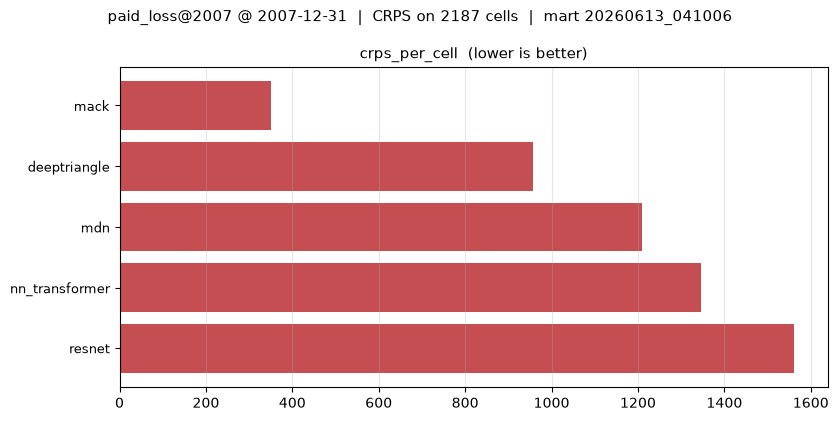

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(board) + 2.0))
order = board.sort_values("crps_per_cell")["model"].tolist()
y = np.arange(len(order))
vals = pd.to_numeric(board.set_index("model").loc[order, "crps_per_cell"], errors="coerce")

ax.barh(y, vals.to_numpy(dtype=float), color="#c44e52")
ax.set_yticks(y, order, fontsize=9)
ax.invert_yaxis()
ax.set_title("crps_per_cell  (lower is better)", fontsize=11)
ax.axvline(0, color="black", lw=0.6)
ax.grid(axis="x", alpha=0.3)
fig.suptitle(
    f"{TASK} @ {panel.as_of}  |  CRPS on {panel.n_cells_for('crps')} cells  |  mart {PUBLISH_ID}",
    fontsize=11,
)
fig.tight_layout()
plt.show()

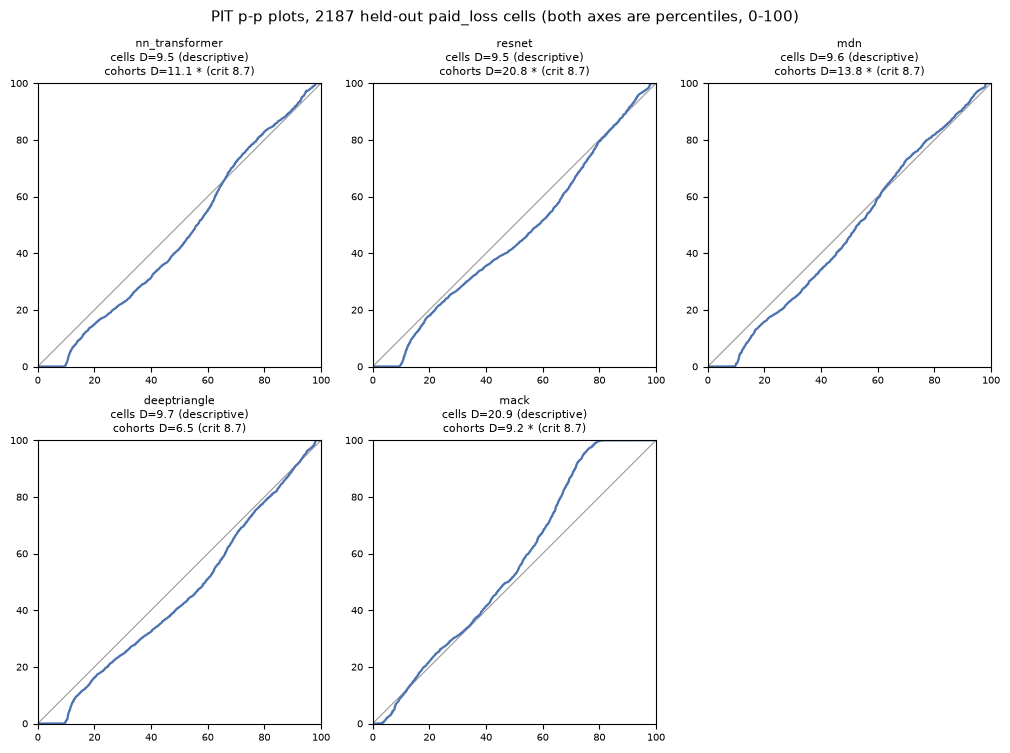

5 panels, [2187] points each, on 0-100 axes


In [21]:
# pp_points returns PERCENTILES - (expected * 100, sorted PIT * 100), the
# convention of the Meyers monograph. So the axes and the reference
# diagonal run 0-100 as well.
#
# The curves are the CELL-level PITs and are descriptive; the D values in each
# title carry the cohort-level statistic beside them for comparison.
models = ks.sort_values("D x 100")["model"].tolist()
ncol = min(3, len(models))
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.8 * nrow), squeeze=False)
n_points = {}
_kc = ks_cohort.set_index("model")
for ax, m in zip(axes.ravel(), models):
    x, y = pp_points(pits[m])
    n_points[m] = len(x)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, color="#4c72b0")
    r = ks.set_index("model").loc[m]
    rc = _kc.loc[m]
    flag = "" if rc["passes"] else " *"
    ax.set_title(
        f"{m}\ncells D={r['D x 100']:.1f} (descriptive)\n"
        f"cohorts D={rc['D x 100']:.1f}{flag} (crit {rc['critical 5% x 100']:.1f})",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(models) :]:
    ax.axis("off")
fig.suptitle(
    f"PIT p-p plots, {panel.n_cells_for('crps')} held-out {FIELD} cells "
    "(both axes are percentiles, 0-100)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

# This assert checks that every point lies inside the axes, instead of trusting
# visual inspection.
assert set(n_points.values()) == {panel.n_cells_for("crps")}, n_points
print(f"{len(n_points)} panels, {sorted(set(n_points.values()))} points each, on 0-100 axes")

## The multi-line transformer

`nn_transformer_ml` is the entry this notebook exists to run. Everything on the board
above models one triangle at a time: the pooled entries are trained across cohorts, but
each cohort's forecast is produced alone, so a company's commercial auto and workers
compensation reserves come out of two sampling paths that share nothing but the fitted
weights and, within a draw, the ensemble member. The multi-line transformer changes the
unit of modelling: **one training example is one company**, all of its lines at once,
and the encoder runs self-attention over every cell of every line - so a workers
compensation cell at 36 months can condition directly on what the same company's
commercial auto line reported at any age. The architecture section at the end of the
notebook opens the entry up properly; three facts matter here.

**Cross-line dependence enters the draws through a switchable mechanism**,
`config.dependence`. In `"ar"` mode every cell has its own one-dimensional mixture
density, and the rollout samples a diagonal's lines one at a time in a seeded random
order, feeding each sampled line back as context before the next line is drawn -
dependence by conditioning, priced as one full re-encode per line per diagonal. In
`"joint"` mode the head is one mixture of multivariate Gaussians per (origin, dev)
cell-group across the company's line vector, so the covariance between lines is an
explicit learned parameter and a diagonal needs a single forward pass. Both modes are
run here, because the gap between them is itself informative: `"ar"` is what attention
alone buys, `"joint"` adds an explicitly correlated head on top.

**The entry has no held-out board row**, for the reason the capabilities section gave:
its cohort is a company while a held-out cohort is a company-line pair, and the adapter
that bridges them is deliberately deferred in the source. It joins at the 120-month
endpoint through the ordinary gallery calls - `predict(segment=company)` returns the
same target layout as `sur` (per-line-and-origin endpoints, per-line totals, grand
total), and `realized_ultimates` aligns the outcomes to it.

**The cost lives in the rollout, and this notebook pays it rather than capping it.**
Notebook 3b reported that a single pooled fit on its ten-company panel ran past ten
minutes without completing and left the entry out. Here every phase is timed where it
runs - the fit, the one shared rollout that serves all 91 companies, and the company
reads - and the closing table reports the totals. One design fact keeps the bill
payable: the rollout is computed once per fit and cached, so the first `predict()` call
carries the whole simulation and the other ninety are reads.

In [22]:
# Two pooled fits, one per dependence mode. Same training budget as every other neural
# entry in this notebook; the only difference between the two fits is the head and the
# sampling mechanism the config selects.
MLConfig = gallery.get("nn_transformer_ml").config_class

ml_fits: dict[str, object] = {}
ml_seconds: dict[str, dict] = {}
ml_ult_rows: list[dict] = []
ml_company_rows: list[dict] = []
ml_refusals: list[dict] = []
ml_line_draws: dict[tuple[str, tuple[str, str]], np.ndarray] = {}
ml_company_draws: dict[tuple[str, str], np.ndarray] = {}

for row_name, dep in ML_MODES.items():
    t0 = time.perf_counter()
    entry = gallery.fit(
        "nn_transformer_ml",
        tri,
        loss_field=FIELD,
        as_of=AS_OF,
        seed=SEED_FIT,
        config=MLConfig(**ML_CONFIG, dependence=dep),
    )
    t_fit = time.perf_counter() - t0

    # The first predict() triggers the one shared rollout over every company; the
    # cache is keyed on (n_draws, seed), so the remaining companies are reads.
    t0 = time.perf_counter()
    _first = entry.predict(segment={"company_code": next(iter(PANEL))}, seed=SEED_DRAW)
    t_roll = time.perf_counter() - t0

    t0 = time.perf_counter()
    for company, lines in PANEL.items():
        ctri = tri.filter(tri.expr.company_code == company)
        try:
            pred = entry.predict(segment={"company_code": company}, seed=SEED_DRAW)
            outcome = np.asarray(
                entry.realized_ultimates(ctri, segment={"company_code": company}), dtype=float
            )
        except Exception as exc:
            ml_refusals.append(dict(model=row_name, company_code=company, error=repr(exc)[:180]))
            continue
        labels = pred.targets["label"].astype(str).tolist()
        cdf_at = pred.cdf(outcome)
        for ln in lines:
            i = labels.index(f"{ln}/total")
            ml_line_draws[(row_name, (company, ln))] = np.asarray(pred.samples[:, i], dtype=float)
            ml_ult_rows.append(
                dict(
                    model=row_name,
                    company_code=company,
                    line_of_business=ln,
                    predicted_ultimate=float(pred.mean()[i]),
                    realized_ultimate=float(outcome[i]),
                    premium=float(PREMIUM_TOTAL[(company, ln)]),
                    outcome_pct=100.0 * float(cdf_at[i]),
                )
            )
        i = labels.index("total")
        ml_company_draws[(row_name, company)] = np.asarray(pred.samples[:, i], dtype=float)
        ml_company_rows.append(
            dict(
                model=row_name,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(pred.mean()[i]),
                sd=float(pred.std()[i]),
                realized_total=float(outcome[i]),
                pct_error=100.0 * (float(pred.mean()[i]) - outcome[i]) / outcome[i],
                outcome_pct=100.0 * float(cdf_at[i]),
            )
        )
    t_score = time.perf_counter() - t0
    ml_fits[row_name] = entry
    ml_seconds[row_name] = dict(
        fit=round(t_fit, 1), rollout=round(t_roll, 1), company_reads=round(t_score, 1)
    )
    print(
        f"{row_name:12s} fit {t_fit:7.1f}s | rollout (500 draws, all {len(PANEL)} companies) "
        f"{t_roll:7.1f}s | company reads {t_score:5.1f}s",
        flush=True,
    )

print(f"\nrefusals: {len(ml_refusals)}")
for r in ml_refusals:
    print("  ", r)

nn_ml_ar     fit  1571.5s | rollout (500 draws, all 91 companies)  9823.0s | company reads  32.9s


nn_ml_joint  fit  2347.5s | rollout (500 draws, all 91 companies)  1803.0s | company reads  30.0s



refusals: 0


## 120-month endpoints across methods

Every method lands on this board: the five held-out-board entries, `sur`, and the two
multi-line transformer arms. Each cohort row is a method's predicted 120-month endpoint
for one company-line pair against the value the later statements reported there, with
that cohort's earned premium over the window as the normalizer. `sur` and the multi-line
arms produce a cohort's row as the per-line total of a company-wide joint predictive;
every other method produces it from a per-cohort (or per-cohort-sliced) predictive of
its own.

Two scoring conventions to read the table by. `error_pct_of_premium` is signed and
dollar-weighted - one number for the panel's whole reserve. `crps_pct_of_premium`
averages the per-cohort scores with equal weight, so a small cohort counts as much as a
large one. The PIT column is one observation per cohort from that cohort's own endpoint
draws; with 243 dependent cohorts the critical value is indicative rather than exact,
for the reasons the calibration section gave. The draws column is the sample each CRPS
rests on: 10,000 for `mack` and `sur`, 500 for every neural row (the rollout budget),
and sample CRPS carries an upward bias of order the forecast's spread over the draw
count, so the neural rows pay a small penalty the classical rows do not.

In [23]:
# sur: one fit per company over that company's selected lines; the per-line total rows
# of its joint predictive are its per-cohort endpoints, and its estimated cross-line
# correlation is kept for the dependence section below.
ult_rows: list[dict] = []
ult_draw: dict[tuple[str, tuple[str, str]], np.ndarray] = {}
sur_company_rows: list[dict] = []
sur_company_draws: dict[str, np.ndarray] = {}
sur_corr_rows: list[dict] = []
sur_refusals: list[dict] = []

# the paid endpoints the sections above already produced, off the fits the board scored
for _r in point_rows:
    _key = (_r["company_code"], _r["line_of_business"])
    ult_rows.append(
        dict(
            model=_r["model"],
            company_code=_key[0],
            line_of_business=_key[1],
            predicted_ultimate=_r["predicted_ultimate"],
            realized_ultimate=_r["realized_ultimate"],
            premium=float(PREMIUM_TOTAL[_key]),
            outcome_pct=_r["outcome_pct"],
        )
    )
    ult_draw[(_r["model"], _key)] = ultimate_draws[(_r["model"], _key)]
ult_rows.extend(ml_ult_rows)
ult_draw.update(ml_line_draws)
print(f"{len(ult_rows)} rows carried over from the fits above")

t0 = time.perf_counter()
for company, lines in PANEL.items():
    ctri = tri.filter(tri.expr.company_code == company)
    try:
        entry = gallery.fit("sur", ctri, loss_field=FIELD, as_of=AS_OF)
    except Exception as exc:
        # sur whitens by 1/sqrt(C), so a non-positive cumulative is refused by name. The
        # selection rule requires positive cumulative paid, so a refusal here would be news.
        sur_refusals.append(dict(model="sur", company_code=company, error=repr(exc)[:180]))
        continue
    pred = entry.predict(seed=SEED_DRAW)
    outcome = np.asarray(entry.realized_ultimates(ctri), dtype=float)
    labels = pred.targets["label"].astype(str).tolist()
    cdf_at = pred.cdf(outcome)
    for ln in lines:
        i = labels.index(f"{ln}/total")
        ult_draw[("sur", (company, ln))] = np.asarray(pred.samples[:, i], dtype=float)
        ult_rows.append(
            dict(
                model="sur",
                company_code=company,
                line_of_business=ln,
                predicted_ultimate=float(pred.mean()[i]),
                realized_ultimate=float(outcome[i]),
                premium=float(PREMIUM_TOTAL[(company, ln)]),
                outcome_pct=100.0 * float(cdf_at[i]),
            )
        )
    i = labels.index("total") if "total" in labels else len(labels) - 1
    sur_company_draws[company] = np.asarray(pred.samples[:, i], dtype=float)
    sur_company_rows.append(
        dict(
            model="sur",
            company_code=company,
            n_lines=len(lines),
            predicted_total=float(pred.mean()[i]),
            sd=float(pred.std()[i]),
            realized_total=float(outcome[i]),
            pct_error=100.0 * (float(pred.mean()[i]) - outcome[i]) / outcome[i],
            outcome_pct=100.0 * float(cdf_at[i]),
        )
    )
    corr = entry.pooled_corr_
    off = corr[np.triu_indices_from(corr, k=1)]
    sur_corr_rows.append(
        dict(
            company_code=company,
            n_lines=len(lines),
            mean_cross_line_corr=float(np.mean(off)),
            max_abs=float(np.max(np.abs(off))),
        )
    )
    del entry
fit_seconds["sur"] = round(time.perf_counter() - t0, 1)
print(
    f"sur: {len(sur_company_rows)} company fits in {fit_seconds['sur']:.1f}s; "
    f"{len(sur_refusals)} refusals"
)
for r in sur_refusals:
    print("  ", r)

1700 rows carried over from the fits above


sur: 91 company fits in 71.8s; 0 refusals


In [24]:
# The endpoint board: every method, one field, per-cohort CRPS and PIT off each row's
# own draws - ibnr's own sample-CRPS estimator, the function entry.evaluate() calls, so
# this level is scored by the same rule as the held-out board.
ults = pd.DataFrame(ult_rows)
_board_rows = []
for _model, g in ults.groupby("model", sort=False):
    _keys = [(_model, k) for k in zip(g["company_code"], g["line_of_business"], strict=True)]
    _per_cohort = np.array(
        [
            float(crps_fn(ult_draw[k][:, None], np.asarray([y], dtype=float))[0])
            for k, y in zip(_keys, g["realized_ultimate"], strict=True)
        ]
    )
    _ks = ks_uniformity(g["outcome_pct"].to_numpy() / 100.0)
    _board_rows.append(
        dict(
            model=_model,
            cohorts=len(g),
            predicted_total=float(g["predicted_ultimate"].sum()),
            realized_total=float(g["realized_ultimate"].sum()),
            error_pct_of_premium=100.0
            * float(g["predicted_ultimate"].sum() - g["realized_ultimate"].sum())
            / float(g["premium"].sum()),
            crps_pct_of_premium=float(np.mean(100.0 * _per_cohort / g["premium"].to_numpy())),
            pit_D_x100=100.0 * _ks.statistic,
            critical_5pct_x100=100.0 * _ks.critical_value_5pct,
            passes=not _ks.reject_5pct,
            draws=min(len(ult_draw[k]) for k in _keys),
        )
    )
ult_board = pd.DataFrame(_board_rows).sort_values("crps_pct_of_premium").reset_index(drop=True)
print(
    f"totals in {tri.meta.units}; premium is each cohort's earned premium over accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year}."
)
print(
    "error_pct_of_premium is signed and dollar-weighted - one number for the panel's whole\n"
    "reserve. crps_pct_of_premium averages the per-cohort scores, so a small cohort counts as\n"
    "much as a large one. The PIT is one per cohort, from that cohort's own endpoint draws;\n"
    "its critical value assumes independent cohorts, which cohorts of one company in one\n"
    "calendar year are not. The draws column is the sample each CRPS rests on."
)
# every method should agree about the realized record it is scored against
_spread = ults.groupby(["company_code", "line_of_business"])["realized_ultimate"].agg(
    lambda s: s.max() - s.min()
)
print(f"max disagreement about a cohort's realized endpoint: {_spread.max():.2e}")
display(ult_board.round(3))

totals in USD thousands; premium is each cohort's earned premium over accident years 1998-2007.
error_pct_of_premium is signed and dollar-weighted - one number for the panel's whole
reserve. crps_pct_of_premium averages the per-cohort scores, so a small cohort counts as
much as a large one. The PIT is one per cohort, from that cohort's own endpoint draws;
its critical value assumes independent cohorts, which cohorts of one company in one
calendar year are not. The draws column is the sample each CRPS rests on.
max disagreement about a cohort's realized endpoint: 0.00e+00


,model,cohorts,predicted_total,realized_total,error_pct_of_premium,crps_pct_of_premium,pit_D_x100,critical_5pct_x100,passes,draws
0,deeptriangle,243,1.859225e+08,176863516.0,3.587,3.058,22.918,8.724,False,500
1,nn_transformer,243,1.905716e+08,176863516.0,5.428,3.418,14.129,8.724,False,500
2,mdn,243,1.859605e+08,176863516.0,3.602,3.683,11.495,8.724,False,500
3,resnet,243,1.912610e+08,176863516.0,5.701,3.880,31.374,8.724,False,500
4,nn_ml_joint,243,1.828002e+08,176863516.0,2.351,4.111,20.048,8.724,False,500
5,mack,242,1.767967e+08,176858070.0,-0.024,4.155,15.204,8.742,False,10000
6,nn_ml_ar,243,1.861232e+08,176863516.0,3.667,4.446,21.452,8.724,False,500
7,sur,243,1.769106e+08,176863516.0,0.019,5.740,15.502,8.724,False,10000


The table reduces each method to a few summaries. The figure keeps the draws. A
method's panel-total endpoint is the sum of its per-cohort endpoints, taken within a
draw. The width of each distribution is that method's own statement of how far the
panel's total reserve could still move. The vertical line is the total the later
statements revealed.

The Monte Carlo construction matches each method's dependence assumption. Separate Mack
cohort fits receive stable, distinct RNG streams before their draws are summed. Each
`sur` fit produces a joint draw across one company's lines, and each multi-line
transformer arm produces a joint draw across one company's lines from one global
rollout; distinct company fits (for `sur`) and distinct companies within the rollout
share nothing except - for the pooled neural entries - the ensemble member selected by
the draw index. A method that produced no endpoint for some cohort covers a smaller
panel, so its total is not comparable with the line and the figure leaves it out.

7 methods cover the whole panel and agree about its realized total to 0.0e+00


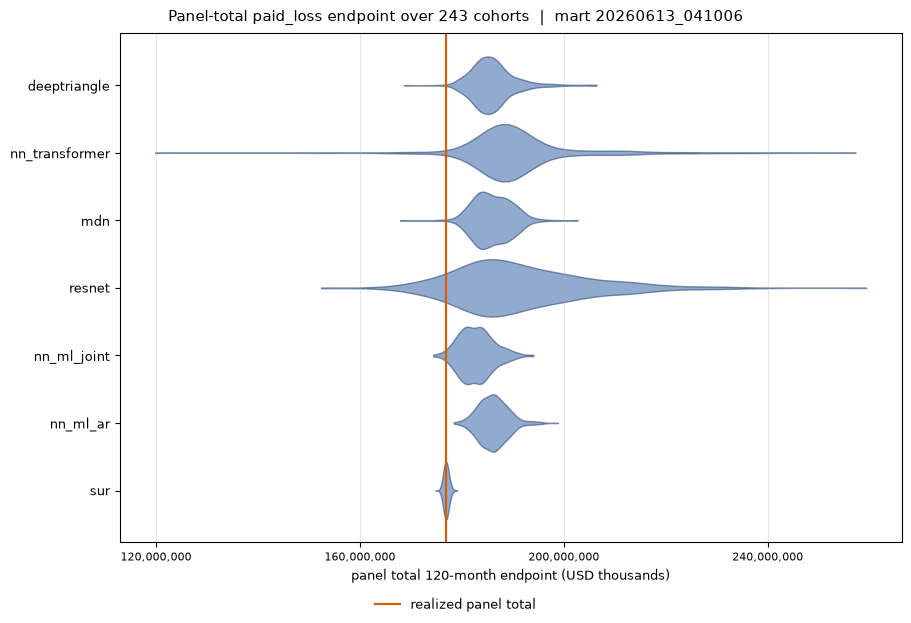

In [25]:
# Panel-total endpoints, from the same draws the table scored.
from matplotlib.lines import Line2D

panel_draws: dict[str, np.ndarray] = {}
for _model, g in ults.groupby("model", sort=False):
    _keys = [(_model, k) for k in zip(g["company_code"], g["line_of_business"], strict=True)]
    if len(_keys) != len(COHORTS) or len({len(ult_draw[k]) for k in _keys}) != 1:
        continue  # a within-draw sum needs the whole panel and one draw axis
    panel_draws[_model] = np.sum([ult_draw[k] for k in _keys], axis=0)

_vals = [
    float(g["realized_ultimate"].sum())
    for m, g in ults.groupby("model", sort=False)
    if m in panel_draws
]
realized_panel = float(np.median(_vals))
print(
    f"{len(_vals)} methods cover the whole panel and agree about its realized total "
    f"to {max(_vals) / min(_vals) - 1:.1e}"
)

names = [m for m in ult_board["model"] if m in panel_draws]
fig, ax = plt.subplots(figsize=(9.0, 0.62 * len(names) + 1.8), layout="constrained")
pos = np.arange(len(names))
parts = ax.violinplot(
    [panel_draws[m] for m in names],
    positions=pos,
    orientation="horizontal",
    showextrema=False,
    widths=0.85,
)
for body in parts["bodies"]:
    body.set_facecolor("#4c72b0")
    body.set_edgecolor("#2c4a75")
    body.set_alpha(0.6)
ax.axvline(realized_panel, color="#D55E00", lw=1.6)
ax.set_yticks(pos, names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel(f"panel total 120-month endpoint ({tri.meta.units})", fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
ax.xaxis.set_major_formatter(lambda v, _p: f"{v:,.0f}")
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="x", alpha=0.3)
fig.legend(
    handles=[Line2D([], [], color="#D55E00", lw=1.6, label="realized panel total")],
    loc="outside lower center",
    frameon=False,
    fontsize=9,
)
fig.suptitle(
    f"Panel-total {FIELD} endpoint over {len(COHORTS)} cohorts  |  mart {PUBLISH_ID}",
    fontsize=11,
)
plt.show()

## Company totals: summed lines against joint models

This is the section the opening question lives in. A company's total reserve is what
capital rests on, and the difference between summing per-line predictions and modelling
the lines jointly is exactly the cross-line dependence question.

Every model lands on one footing:

* each single-line entry's company total is the within-draw sum of its per-line
  endpoint draws - the independence assumption written out (softened, for the pooled
  neural entries, by the ensemble member the draw index shares across cohorts);
* `sur`'s company total comes from its own joint predictive;
* each multi-line transformer arm's company total is the `total` row of its own joint
  predictive - the row-sum of the same draws that produced its per-line rows, so
  whatever dependence the model expressed is priced into the width.

The PIT of a company's realized total is then one observation per company for every
model - n = 91 on the same companies, against notebook 3b's ten. One shared calendar
year still limits what a rejection can mean.

In [26]:
# Company totals for every model on one footing. The realized record per cohort is a
# property of the data; the median across models tolerates a model that missed a cohort.
_realized = ults.groupby(["company_code", "line_of_business"])["realized_ultimate"].median()
company_rows: list[dict] = []
for model in sorted({k[0] for k in ultimate_draws}):
    for company, lines in PANEL.items():
        keys = [(model, (company, ln)) for ln in lines]
        if not all(k in ultimate_draws for k in keys):
            continue  # this model did not produce an endpoint for every line
        if len({len(ultimate_draws[k]) for k in keys}) != 1:
            continue  # draw counts differ, so a within-draw sum is not defined
        draws = np.sum([ultimate_draws[k] for k in keys], axis=0)
        realized = float(sum(_realized.loc[(company, ln)] for ln in lines))
        company_rows.append(
            dict(
                model=model,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(draws.mean()),
                sd=float(draws.std(ddof=1)),
                realized_total=realized,
                pct_error=100.0 * (draws.mean() - realized) / realized,
                outcome_pct=100.0 * float((draws <= realized).mean()),
            )
        )
company_rows.extend(sur_company_rows)
company_rows.extend(ml_company_rows)
ult = pd.DataFrame(company_rows)
ult["premium"] = ult["company_code"].map(
    {c: float(sum(PREMIUM_TOTAL[(c, ln)] for ln in ls)) for c, ls in PANEL.items()}
)
ult["error_pct_premium"] = 100.0 * (ult["predicted_total"] - ult["realized_total"]) / ult["premium"]

# The realized total is a property of the data, not of the model, so every model that
# covered a company should agree on it. Printed rather than asserted: each entry
# restricts origins its own way, and a disagreement is worth seeing rather than
# crashing on.
_spread = ult.groupby("company_code")["realized_total"].agg(lambda s: s.max() / s.min() - 1.0)
print(f"max relative disagreement about a company's realized total: {_spread.max():.2e}")

ult_summary = (
    ult.groupby("model")
    .agg(
        companies=("company_code", "nunique"),
        median_pct_error=("pct_error", "median"),
        mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
        mean_abs_error_pct_premium=("error_pct_premium", lambda s: s.abs().mean()),
        median_sd_pct_premium=("sd", "median"),  # rescaled below
        median_outcome_pct=("outcome_pct", "median"),
    )
    .sort_values("mean_abs_error_pct_premium")
)
_sd_prem = 100.0 * ult["sd"] / ult["premium"]
ult_summary["median_sd_pct_premium"] = _sd_prem.groupby(ult["model"]).median()
print(
    "\nCompany-total 120-month endpoints. mean_abs_error_pct_premium is the\n"
    "premium-normalized reserve error - the metric that survives a panel spanning\n"
    "orders of magnitude of premium. median_sd_pct_premium is each model's own\n"
    "predictive spread on the same scale: the aggregate-uncertainty statement the\n"
    "dependence assumption feeds."
)
display(ult_summary.round(2))

max relative disagreement about a company's realized total: 0.00e+00

Company-total 120-month endpoints. mean_abs_error_pct_premium is the
premium-normalized reserve error - the metric that survives a panel spanning
orders of magnitude of premium. median_sd_pct_premium is each model's own
predictive spread on the same scale: the aggregate-uncertainty statement the
dependence assumption feeds.


,companies,median_pct_error,mean_abs_pct_error,mean_abs_error_pct_premium,median_sd_pct_premium,median_outcome_pct
model,,,,,,
deeptriangle,91,4.23,6.34,3.78,3.40,19.00
nn_transformer,91,4.92,7.77,4.62,5.71,25.00
mdn,91,1.92,7.84,4.81,3.02,41.60
nn_ml_joint,91,3.66,8.97,5.24,3.93,29.80
mack,90,0.27,7.37,5.38,1.53,44.24
resnet,91,7.55,9.58,5.60,5.86,18.00
nn_ml_ar,91,4.08,10.54,6.22,3.57,22.40
sur,91,0.35,9.31,7.17,1.51,41.65


n = [90, 91] companies per model, one shared calendar record. Read the mean PIT
column with the statistic: a mean well below 0.5 says realized totals land in the
lower tail of the predictives far more often than they should, i.e. the
predictives are biased high relative to their own spread.


,model,n_companies,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,mack,90,12.907,14.336,0.100,True,0.475
1,sur,91,16.251,14.257,0.016,False,0.462
2,mdn,91,20.367,14.257,0.001,False,0.427
3,nn_ml_joint,91,25.536,14.257,0.000,False,0.376
4,nn_transformer,91,26.446,14.257,0.000,False,0.354
5,nn_ml_ar,91,31.037,14.257,0.000,False,0.327
6,deeptriangle,91,33.154,14.257,0.000,False,0.320
7,resnet,91,41.725,14.257,0.000,False,0.278


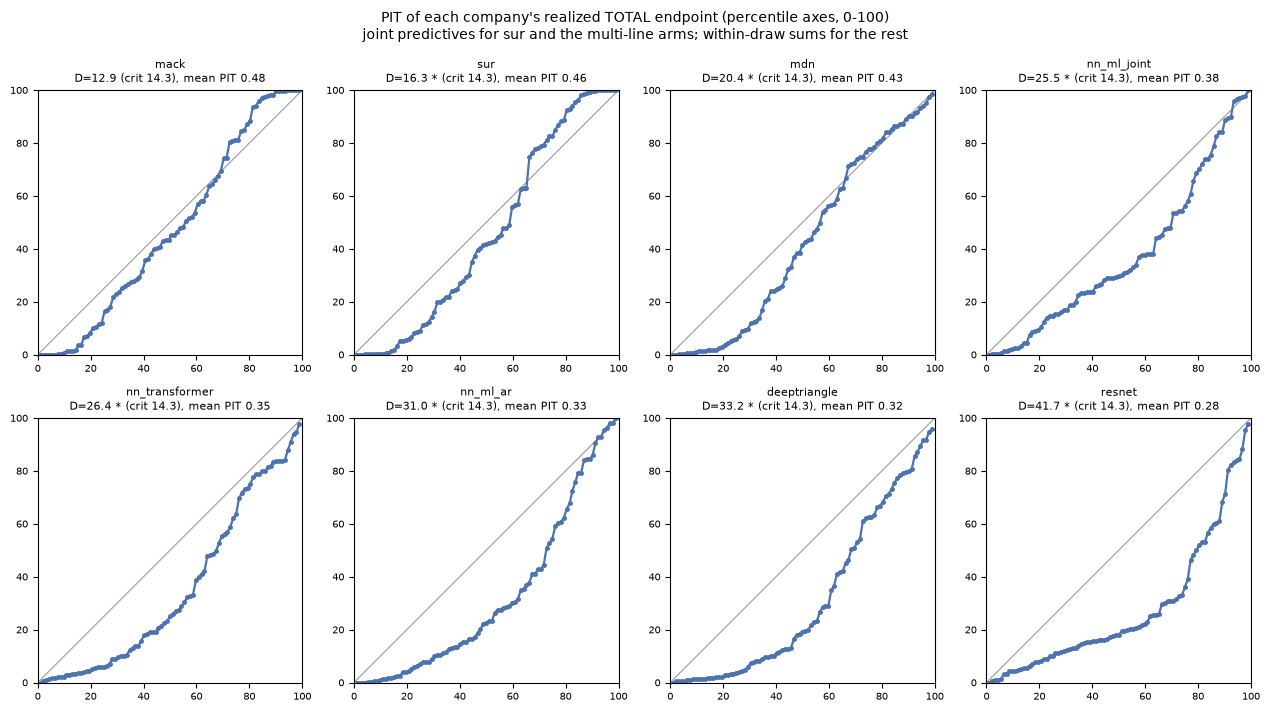

In [27]:
# Calibration at the company level: one PIT per company for every model, same n.
ks_ult = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_companies": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["outcome_pct"].mean() / 100.0),
            }
            for m, g in ult.groupby("model")
            for r in [ks_uniformity(g["outcome_pct"].to_numpy() / 100.0)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
_ns = sorted(set(ks_ult["n_companies"]))
print(
    f"n = {_ns} companies per model, one shared calendar record. Read the mean PIT\n"
    "column with the statistic: a mean well below 0.5 says realized totals land in the\n"
    "lower tail of the predictives far more often than they should, i.e. the\n"
    "predictives are biased high relative to their own spread."
)
display(ks_ult.round(3))

_models = ks_ult["model"].tolist()
ncol = min(4, len(_models))
nrow = int(np.ceil(len(_models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.6 * nrow), squeeze=False)
_ku = ks_ult.set_index("model")
for ax, m in zip(axes.ravel(), _models):
    p = ult.loc[ult["model"] == m, "outcome_pct"].to_numpy() / 100.0
    x, y = pp_points(p)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, marker="o", ms=2.5, color="#4c72b0")
    rc = _ku.loc[m]
    ax.set_title(
        f"{m}\nD={rc['D x 100']:.1f}{'' if rc['passes'] else ' *'} "
        f"(crit {rc['critical 5% x 100']:.1f}), mean PIT {rc['mean_pit']:.2f}",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(_models) :]:
    ax.axis("off")
fig.suptitle(
    "PIT of each company's realized TOTAL endpoint (percentile axes, 0-100)\n"
    "joint predictives for sur and the multi-line arms; within-draw sums for the rest",
    fontsize=10,
)
fig.tight_layout()
plt.show()

### The cross-line correlation each model implies

The dependence question has a directly inspectable answer: for each company, correlate
each pair of its lines' total-endpoint draws and average the off-diagonal. This is one
statistic computed the same way for every model, from the same draws the boards above
scored, so the models' dependence assumptions are compared like for like:

* `mack` fits every cohort independently with distinct RNG streams, so its implied
  correlation is a sampling-noise zero - the negative control;
* the pooled single-line entries share an ensemble member within a draw, so whatever
  correlation they show is what pooling alone induces - the middle case the opening
  question asks about;
* `sur` models contemporaneous cross-line correlation explicitly, and its
  parameter estimate (`pooled_corr_`) is shown beside its draw-implied value;
* the multi-line arms carry dependence through conditioning (`nn_ml_ar`) or through an
  explicitly correlated head (`nn_ml_joint`).

The milestone-3 study measured this on the classic vintage and found joint 0.13/0.08 >
ar 0.04/0.05 > sur and the copula at 0.01-0.02, on reported loss. This is the same
statistic on the new vintage, on paid.

In [28]:
def implied_corr(draws_by_line: dict) -> float | None:
    """Mean off-diagonal correlation across a company's lines' endpoint draws."""
    if len(draws_by_line) < 2:
        return None
    mat = np.vstack([draws_by_line[ln] for ln in sorted(draws_by_line)])
    if np.any(mat.std(axis=1) < 1e-12):
        return None  # a degenerate line would make corrcoef undefined
    corr = np.corrcoef(mat)
    return float(np.mean(corr[np.triu_indices_from(corr, k=1)]))


corr_long: list[dict] = []
_sources = {m: ultimate_draws for m in sorted({k[0] for k in ultimate_draws})}
_sources["sur"] = ult_draw  # sur's per-line draws live in the endpoint dict
for m in ML_MODES:
    _sources[m] = ml_line_draws
for model, source in _sources.items():
    for company, lines in PANEL.items():
        if len(lines) < 2:
            continue
        by_line = {}
        for ln in lines:
            key = (model, (company, ln))
            if key in source:
                by_line[ln] = source[key]
        if len(by_line) < len(lines):
            continue
        if len({len(v) for v in by_line.values()}) != 1:
            continue
        r = implied_corr(by_line)
        if r is not None:
            corr_long.append(dict(model=model, company_code=company, implied_corr=r))
corr_df = pd.DataFrame(corr_long)
corr_summary = (
    corr_df.groupby("model")["implied_corr"]
    .agg(companies="size", mean="mean", median="median", q10=lambda s: s.quantile(0.1), q90=lambda s: s.quantile(0.9))
    .sort_values("mean")
)
display(corr_summary.round(3))
_sur_param = pd.DataFrame(sur_corr_rows)
print(
    "sur's parametric estimate of the same quantity (pooled_corr_, per company): "
    f"mean {_sur_param['mean_cross_line_corr'].mean():.3f}, "
    f"median {_sur_param['mean_cross_line_corr'].median():.3f} "
    f"over {len(_sur_param)} companies"
)

,companies,mean,median,q10,q90
model,,,,,
mdn,91,0.009,0.007,-0.035,0.052
nn_transformer,91,0.009,0.011,-0.026,0.046
nn_ml_ar,91,0.017,0.019,-0.028,0.061
sur,91,0.043,0.045,-0.100,0.194
deeptriangle,91,0.046,0.044,-0.011,0.109
nn_ml_joint,91,0.119,0.116,0.052,0.196
resnet,91,0.149,0.140,0.069,0.232
mack,90,0.255,0.246,0.140,0.374


sur's parametric estimate of the same quantity (pooled_corr_, per company): mean 0.054, median 0.053 over 91 companies


### Reading the boards

**The next-diagonal board's answer depends on the weighting, which it did not in
notebook 3b.** In dollars, `mack` is far ahead: 350 per cell against 957 for the best
neural entry, on a panel where one company carries 63% of the premium. Per unit of
premium the order flips: `deeptriangle` scores 2.12% of premium at equal cohort weight
against `mack`'s 2.19%, holds the lead at equal company weight (2.27 against 2.38),
keeps it when the 243 pinned-step cells are set aside (2.31 against 2.34), and is the
only entry whose 243 cohort-total PITs pass the uniformity test (D = 6.5 against a
critical value of 8.7). Read together: `mack` remains the best answer for the biggest
books' dollars, and the pooled neural entries are the better answer for a typical
cohort on this vintage.

**At the 120-month endpoint the single-line pooled entries lead, and the multi-line
arms land mid-pack.** `deeptriangle` again has the lowest premium-normalized CRPS
(3.06), ahead of `nn_transformer` (3.42) and `mdn` (3.68); `nn_ml_joint` (4.11) and
`mack` (4.16) are effectively tied; `nn_ml_ar` (4.45) and `sur` (5.74) trail. On the
panel's whole reserve the classical methods are nearly unbiased - `mack` at -0.02% of
premium and `sur` at +0.02% - while every neural row overstates the paid total,
`nn_ml_joint` least (+2.35%) and `resnet` most (+5.70%). At the company level
`deeptriangle` has the smallest premium-normalized absolute error (3.78%),
`nn_ml_joint` (5.24%) edges `mack` (5.38%), and `sur` (7.17%) is last despite carrying,
alongside `mack`, the narrowest predictive spread on the panel (median near 1.5% of
premium).

**The correlation table is the dependence question answered in one column, with one
artifact to subtract first.** Pooled training alone produces essentially nothing:
`mdn` and `nn_transformer` imply 0.009. Attention plus line-by-line conditioning adds
little: `nn_ml_ar` implies 0.017. `sur` estimates 0.054 by parameter and 0.043 by
draws. The explicitly correlated head is where dependence actually appears:
`nn_ml_joint` implies 0.119, about twice `sur`'s estimate - the same ordering, at
similar sizes, that the milestone-3 study measured on reported loss on the classic
vintage. Two pooled single-line rows are a caution rather than a finding:
`deeptriangle` (0.046) and `resnet` (0.149) reach or pass `sur`'s value purely through
the ensemble member their draw index shares across cohorts, so an implied correlation
from a pooled entry is not evidence of learned dependence on its own.

**The `mack` row of that table, 0.255, is a random-number artifact, and it teaches the
right lesson.** This notebook passes the same draw seed to every per-cohort
`predict()` call, and `mack` restarts its random stream from that seed on every fit -
so draw i of a company's commercial auto fit and draw i of its workers compensation
fit consume the same noise and come out strongly correlated. That is common random
numbers, not dependence. Three numbers above inherit it: the 0.255 itself; `mack`'s
company-total spread, which the induced correlation overstates; and `mack`'s
company-level calibration pass, which the overstated spread flatters. `sur` restarts
the same way, so its cross-company sums in the panel-total figure share the artifact
one level up. The limitations section records it, and the fix - deriving a distinct
stream per cohort from one seed inside the entry - is library work rather than
notebook work.

**So: does explicit cross-line attention improve forecasts and aggregate uncertainty
beyond both classical multivariate models and neural models that merely pool training
data?** On this panel, in three parts. On forecast accuracy: no - the best pooled
single-line entry beats both multi-line arms at both levels they can be measured on,
and the joint arm only matches `mack`. Against the classical multivariate baseline
specifically: yes - `nn_ml_joint` is more accurate than `sur` at the cohort and
company levels while expressing about twice the cross-line correlation, which is the
aggregate-uncertainty statement a multivariate method exists to make. On mechanism:
the dependence lives in the explicitly correlated head, not in the attention - the
`"ar"` arm, which is attention plus conditioning alone, implies almost none and
scores worse. And the cost that kept this model out of notebook 3b is now a number:
on this machine the joint arm's whole pipeline is about an hour (39 minutes of
fitting, 30 of rollout) and the `"ar"` arm about three and a quarter hours, 2.7 of
them the rollout's one-forward-pass-per-line-per-diagonal price.

**One calibration caveat covers every row.** All the company-level mean PITs sit at or
below 0.5 - realized totals landing low in the predictives - and every neural row
fails the company-level uniformity test. That can be miscalibration, and it can
equally be this design's single shared outcome record: paid development over
2008-2016 for accident years 1998-2007 is one draw of one calendar history for
everyone at once. The rolling-cutoff study the limitations section asks for is what
would separate the two.

### How much of a gap is the training seed?

Every multi-line number above comes from one training run at one seed. Before reading a
gap between the two arms - or between an arm and its single-line neighbour - as a
difference between methods, it is worth measuring what changing nothing but the training
seed does. The two multi-line fits are repeated below at one alternate seed and scored
through the same per-company loop on the same panel. The numbers land in a table of
their own: every board above stays on seed 11 alone. Two seeds are a sensitivity check,
not an estimate of training variability, and they do not cover the single-line roster.

In [29]:
SEED_ALT = 12
seed_rows: list[dict] = []
for row_name, dep in ML_MODES.items():
    _b = ult_board[ult_board["model"] == row_name].iloc[0]
    _k = ks_ult.set_index("model").loc[row_name]
    seed_rows.append(
        dict(
            model=row_name,
            seed=SEED_FIT,
            crps_pct_of_premium=float(_b["crps_pct_of_premium"]),
            error_pct_of_premium=float(_b["error_pct_of_premium"]),
            company_pit_D_x100=float(_k["D x 100"]),
        )
    )
    t0 = time.perf_counter()
    entry = gallery.fit(
        "nn_transformer_ml",
        tri,
        loss_field=FIELD,
        as_of=AS_OF,
        seed=SEED_ALT,
        config=MLConfig(**ML_CONFIG, dependence=dep),
    )
    _rows, _company_pits = [], []
    for company, lines in PANEL.items():
        ctri = tri.filter(tri.expr.company_code == company)
        pred = entry.predict(segment={"company_code": company}, seed=SEED_DRAW)
        outcome = np.asarray(
            entry.realized_ultimates(ctri, segment={"company_code": company}), dtype=float
        )
        labels = pred.targets["label"].astype(str).tolist()
        cdf_at = pred.cdf(outcome)
        for ln in lines:
            i = labels.index(f"{ln}/total")
            _rows.append(
                dict(
                    draws=np.asarray(pred.samples[:, i], dtype=float),
                    predicted=float(pred.mean()[i]),
                    realized=float(outcome[i]),
                    premium=float(PREMIUM_TOTAL[(company, ln)]),
                )
            )
        _company_pits.append(float(cdf_at[labels.index("total")]))
    _per_cohort = np.array(
        [
            float(crps_fn(r["draws"][:, None], np.asarray([r["realized"]], dtype=float))[0])
            / r["premium"]
            for r in _rows
        ]
    )
    seed_rows.append(
        dict(
            model=row_name,
            seed=SEED_ALT,
            crps_pct_of_premium=float(np.mean(100.0 * _per_cohort)),
            error_pct_of_premium=100.0
            * float(sum(r["predicted"] - r["realized"] for r in _rows))
            / float(sum(r["premium"] for r in _rows)),
            company_pit_D_x100=100.0 * ks_uniformity(np.asarray(_company_pits)).statistic,
        )
    )
    ml_seconds[f"{row_name} @ seed {SEED_ALT}"] = {
        "fit + rollout + scoring": round(time.perf_counter() - t0, 1)
    }
    del entry
    print(f"{row_name} @ seed {SEED_ALT}: {time.perf_counter() - t0:7.1f}s", flush=True)

seed_table = pd.DataFrame(seed_rows).sort_values(["model", "seed"]).reset_index(drop=True)
print("\nsame panel, same draws seed, same configuration - only the training seed differs")
display(seed_table.round(3))

nn_ml_ar @ seed 12: 13141.1s


nn_ml_joint @ seed 12:  4177.1s



same panel, same draws seed, same configuration - only the training seed differs


,model,seed,crps_pct_of_premium,error_pct_of_premium,company_pit_D_x100
0,nn_ml_ar,11,4.446,3.667,31.037
1,nn_ml_ar,12,4.088,2.889,24.952
2,nn_ml_joint,11,4.111,2.351,25.536
3,nn_ml_joint,12,3.853,2.007,22.042


The ordering between the two arms survives the seed: `nn_ml_joint` beats `nn_ml_ar` on
all three columns at both seeds. The sizes do not: refitting either arm with nothing
changed but the training seed moves its CRPS by 0.26-0.36 points of premium - roughly
the size of the gap between the two arms, and several times the gap between the joint
arm and `mack`, which has no training seed and does not move. So the defensible
statements are the ones that clear the seed movement. `deeptriangle`'s lead over both
multi-line arms - about a full point of premium - stands. The joint arm's advantage
over the ar arm is consistent in direction at both seeds but comparable in size with
training variation. And "the joint arm ties `mack`" should be read as "sits within
seed movement of `mack`": at the alternate seed it lands below it (3.85 against 4.16).
The aggregate bias column tells the same story with the same caution - both arms
overstate the panel's paid total at both seeds, the joint arm less at each. Two seeds
are a sensitivity check, not a distribution, and the single-line rows were not refit
at all.

## Inside the multi-line transformer

Everything above arrived through one call, `gallery.fit("nn_transformer_ml", ...)`.
Notebook 3b's closing appendix opens up the single-line `nn_transformer`; this section
does the same for the multi-line entry, and everything the single-line appendix
establishes - incremental loss ratios as the target, per-development-step
standardization with pinned sparse steps, calendar-cutoff augmentation, the mixture
density idea, the five-member deep ensemble - carries over unchanged. What follows is
what the multi-line entry adds. Line references point into the installed package at
version 0.5.6.

### One company is one example

`ibnr/kernels/nn_contract.py:498` (`nn_company_data`) is the multi-line sibling of the
`nn_data` contract: it returns arrays shaped `(companies, lines, channels, origins,
devs)` plus a `line_mask` saying which lines each company writes, with absent lines
carried as padding. `fit()` calls it on the as-of slice
(`ibnr/gallery/nn/transformer_ml/model.py:110`), so no post-2007 outcome enters the
contract. The target channel is the same incremental paid ratio as the single-line
entry's; the standardization runs the same pinned per-development rule once per line
(`model.py:142`), so the deepest steps of each line are pinned exactly as they are on
the single-line entry, and rollout draws there are replaced by the pooled development
mean.

### The forward pass

The network (`ibnr/gallery/nn/transformer_ml/network.py:38`) flattens one company's
whole `(line, origin, dev)` grid to a single token sequence - six lines of a 10x10
grid make 600 tokens - and runs standard self-attention over all of them with no
attention mask between lines (`network.py:128-176`). Every token receives five added
signals: the cell's value channels, a line embedding, an origin embedding, a
development embedding, a distance-past-cutoff embedding, and the line's normalized log
premium. Lines the company does not write are excluded through the padding mask, so
they neither attend nor are attended to. This is the step the single-line entry has no
analogue for: a workers compensation cell can attend to a commercial auto cell of the
same company, at any age, and the attention weights decide whether that is useful.

### Two heads, two routes to dependence

The config's `dependence` field selects the head and with it the sampling mechanism
(`config.py:49`):

* **`"ar"`** (`network.py:178`) - the single-line entry's head, unchanged: an
  independent univariate Gaussian mixture per cell. Dependence between lines is not in
  these parameters; it is created by the rollout, which samples a diagonal's lines one
  at a time in a seeded random order and re-encodes the grid after each, so line B's
  draw conditions on line A's sampled value (`model.py:435-454`). The price is one full
  forward pass per line per diagonal.
* **`"joint"`** (`network.py:193`) - one mixture of L-variate Gaussians per
  (origin, dev) cell-group, its scale a learned Cholesky factor, fed by the mean of the
  present lines' token states. The whole line vector is drawn in one shot
  (`model.py:455-465`), covariance is an explicit parameter, and a diagonal needs a
  single forward pass.

### The rollout, and why it was expensive

`_rollout` (`model.py:343`) simulates every company at once, one calendar diagonal at a
time: sample the diagonal, write the target channel back as context, re-encode, step
forward. Draw replicas are batched, capped at roughly 2,048 company-replicas per
forward pass (`model.py:33`), and the whole simulation is cached on `(n_draws, seed)` -
which is why the first `predict()` call above carries the entire cost and the other
ninety are reads. The `"ar"` arm multiplies the per-diagonal work by the number of
lines; that multiplier is what notebook 3b's ten-minute measurement met, and the timing
table above prices both arms on this panel honestly.

### What the two diagrams show

The first diagram is the data layout: one company's lines stacked into one token
sequence, attention across all of it. The second is the two sampling routes through one
predicted diagonal. Between them they are the whole difference between this entry and
its single-line sibling; everything else is shared machinery.

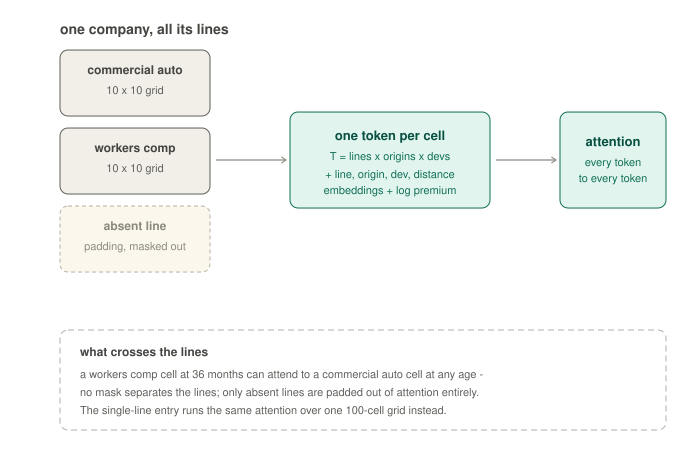

In [30]:
# one company = one example
DAG_ML_TOKENS = """<svg width="680" height="470" viewBox="0 0 680 470" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer_ml tokenization</title>
<defs><marker id="dagml-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<text x="60" y="34" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">one company, all its lines</text>
<g>
<rect x="60" y="50" width="150" height="66" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="135" y="74" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">commercial auto</text>
<text x="135" y="94" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">10 x 10 grid</text>
</g>
<g>
<rect x="60" y="128" width="150" height="66" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="135" y="152" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">workers comp</text>
<text x="135" y="172" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">10 x 10 grid</text>
</g>
<g>
<rect x="60" y="206" width="150" height="66" rx="8" fill="#FBF7EC" stroke="#B4B2A9" stroke-dasharray="4 3"/>
<text x="135" y="230" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#8A8880">absent line</text>
<text x="135" y="250" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#8A8880">padding, masked out</text>
</g>
<line x1="216" y1="160" x2="286" y2="160" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagml-arrow)"/>
<g>
<rect x="290" y="112" width="200" height="96" rx="8" fill="#E1F5EE" stroke="#0F6E56"/>
<text x="390" y="140" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="600" fill="#085041">one token per cell</text>
<text x="390" y="160" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">T = lines x origins x devs</text>
<text x="390" y="178" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">+ line, origin, dev, distance</text>
<text x="390" y="194" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">embeddings + log premium</text>
</g>
<line x1="496" y1="160" x2="556" y2="160" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagml-arrow)"/>
<g>
<rect x="560" y="112" width="106" height="96" rx="8" fill="#E1F5EE" stroke="#0F6E56"/>
<text x="613" y="146" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="600" fill="#085041">attention</text>
<text x="613" y="166" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">every token</text>
<text x="613" y="182" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">to every token</text>
</g>
<g>
<rect x="60" y="330" width="606" height="100" rx="8" fill="none" stroke="#B4B2A9" stroke-dasharray="6 4"/>
<text x="80" y="356" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">what crosses the lines</text>
<text x="80" y="378" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">a workers comp cell at 36 months can attend to a commercial auto cell at any age -</text>
<text x="80" y="396" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">no mask separates the lines; only absent lines are padded out of attention entirely.</text>
<text x="80" y="414" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">The single-line entry runs the same attention over one 100-cell grid instead.</text>
</g>
</svg>"""

display(SVG(DAG_ML_TOKENS))

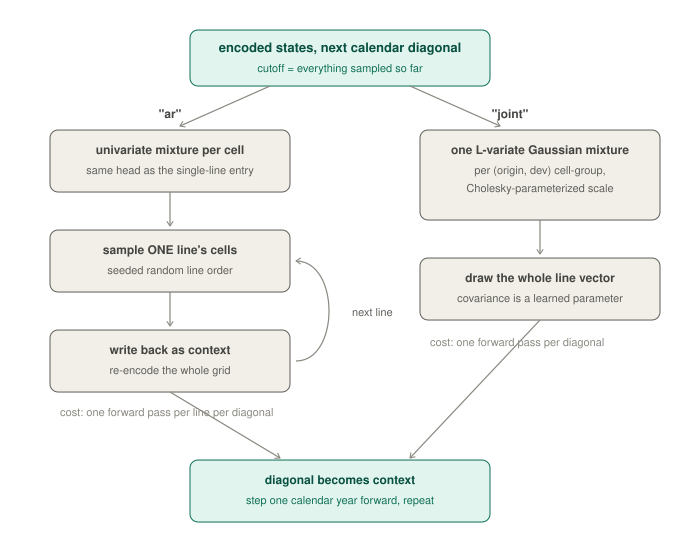

In [31]:
# two routes from encoded states to one predicted diagonal
DAG_ML_HEADS = """<svg width="680" height="560" viewBox="0 0 680 560" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer_ml dependence modes</title>
<defs><marker id="dagmh-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<g>
<rect x="190" y="30" width="300" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56"/>
<text x="340" y="52" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="600" fill="#085041">encoded states, next calendar diagonal</text>
<text x="340" y="72" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">cutoff = everything sampled so far</text>
</g>
<line x1="270" y1="86" x2="180" y2="126" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<line x1="410" y1="86" x2="500" y2="126" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<text x="170" y="118" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">"ar"</text>
<text x="510" y="118" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">"joint"</text>
<g>
<rect x="50" y="130" width="240" height="62" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="170" y="154" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">univariate mixture per cell</text>
<text x="170" y="174" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">same head as the single-line entry</text>
</g>
<line x1="170" y1="192" x2="170" y2="226" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<g>
<rect x="50" y="230" width="240" height="62" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="170" y="254" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">sample ONE line's cells</text>
<text x="170" y="274" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">seeded random line order</text>
</g>
<line x1="170" y1="292" x2="170" y2="326" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<g>
<rect x="50" y="330" width="240" height="62" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="170" y="354" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">write back as context</text>
<text x="170" y="374" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">re-encode the whole grid</text>
</g>
<path d="M 296 361 C 340 361 340 261 296 261" fill="none" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<text x="352" y="316" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">next line</text>
<text x="60" y="416" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#8A8880">cost: one forward pass per line per diagonal</text>
<g>
<rect x="420" y="130" width="240" height="90" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="540" y="154" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">one L-variate Gaussian mixture</text>
<text x="540" y="174" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">per (origin, dev) cell-group,</text>
<text x="540" y="192" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">Cholesky-parameterized scale</text>
</g>
<line x1="540" y1="220" x2="540" y2="254" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<g>
<rect x="420" y="258" width="240" height="62" rx="8" fill="#F1EFE8" stroke="#5F5E5A"/>
<text x="540" y="282" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#444441">draw the whole line vector</text>
<text x="540" y="302" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#5F5E5A">covariance is a learned parameter</text>
</g>
<text x="430" y="346" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#8A8880">cost: one forward pass per diagonal</text>
<g>
<rect x="190" y="460" width="300" height="62" rx="8" fill="#E1F5EE" stroke="#0F6E56"/>
<text x="340" y="484" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="600" fill="#085041">diagonal becomes context</text>
<text x="340" y="504" text-anchor="middle" font-family="Helvetica,Arial,sans-serif" font-size="11" fill="#0F6E56">step one calendar year forward, repeat</text>
</g>
<line x1="170" y1="392" x2="280" y2="458" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
<line x1="540" y1="320" x2="410" y2="458" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagmh-arrow)"/>
</svg>"""

display(SVG(DAG_ML_HEADS))

### A live forward pass

The diagrams above are hand-drawn; this cell is not. It builds the same company
contract `fit()` builds, constructs an untrained network with the same config the fits
above used, and reports the shape at every stage of a real forward pass through both
heads, captured with PyTorch forward hooks on the live modules, so the shapes are what
actually flowed rather than a recomputation. It also prints the parameter count and the
pinned development steps per line.

Nothing here is trained: it is the architecture, read from the installed package.

In [32]:
import torch

from ibnr.gallery.nn.transformer_ml.config import TransformerMLConfig as _MLCfg
from ibnr.gallery.nn.transformer_ml.network import TriangleTransformerML as _MLNet
from ibnr.kernels.nn_contract import nn_company_data as _nn_company_data

_c = _nn_company_data(
    tri.as_of(AS_OF), loss_field=FIELD, feature_fields=(), level_fields=(), premium_field=PREMIUM_FIELD
)
_n_c, _n_l, _n_f, _n_w, _n_d = _c["x"].shape
print(
    f"contract: {_n_c} companies x {_n_l} lines x {_n_f} channel(s) x "
    f"{_n_w} origins x {_n_d} devs"
)
print(f"tokens per company: {_n_l} x {_n_w} x {_n_d} = {_n_l * _n_w * _n_d}")
print(f"lines written per company: {sorted(pd.Series(_c['line_mask'].sum(axis=1)).value_counts().to_dict().items())}")

# pinned steps per line, read off the FITTED entry's own normalizer (channel 0 = target)
_pinned_ml = ml_fits["nn_ml_joint"].norm_["pinned"]
print("pinned development steps by line (months), from the joint fit's normalizer:")
for _li, _lob in enumerate(_c["lob_levels"]):
    _devs = sorted(int(d) for d in (np.nonzero(_pinned_ml[_li, 0])[0] + 1) * 12)
    print(f"  {_lob:24s} {_devs}")

# The network builds ONE head per config - `head` under "ar", `joint_head` under
# "joint" - so the two modes are two networks sharing every encoder parameter count.
_B = 4
_x = torch.tensor(np.where(_c["x_obs"][:_B], _c["x"][:_B], 0.0), dtype=torch.float32)
_ctx = torch.tensor(_c["x_obs"][:_B])
_lm = torch.tensor(_c["line_mask"][:_B])
_prem = torch.zeros((_B, _n_l))
_cut = torch.full((_B,), int(_c["cal_idx"].max()), dtype=torch.long)

_shapes: list[tuple[str, tuple]] = []


def _hook(name):
    def fn(mod, args, out):
        t = out[0] if isinstance(out, tuple) else out
        if hasattr(t, "shape"):
            _shapes.append((name, tuple(t.shape)))

    return fn


for _dep in ("ar", "joint"):
    torch.manual_seed(0)
    _net = _MLNet(_MLCfg(**ML_CONFIG, dependence=_dep), n_lines=_n_l, n_features=_n_f, n_w=_n_w, n_d=_n_d)
    _net.eval()
    print(f"\n[{_dep}] parameters: {sum(p.numel() for p in _net.parameters()):,}")
    if _dep == "ar":
        for _name, _mod in _net.named_children():
            _mod.register_forward_hook(_hook(_name))
        with torch.no_grad():
            _log_pi, _mu, _sigma = _net.forward_ar(_x, _ctx, _lm, _prem, _cut)
        print(f"  stage shapes through the shared encoder, batch of {_B} companies:")
        for _nm, _sh in _shapes:
            print(f"    {_nm:16s} -> {_sh}")
        print(
            f"  forward_ar: log_pi {tuple(_log_pi.shape)}  mu {tuple(_mu.shape)}  "
            f"sigma {tuple(_sigma.shape)}"
        )
    else:
        with torch.no_grad():
            _jlog_pi, _jmu, _jscale = _net.forward_joint(_x, _ctx, _lm, _prem, _cut)
        print(
            f"  forward_joint: log_pi {tuple(_jlog_pi.shape)}  mu {tuple(_jmu.shape)}  "
            f"scale_tril {tuple(_jscale.shape)}"
        )

print(
    "\nar: one univariate mixture per (line, origin, dev) cell. joint: one mixture of\n"
    f"{_n_l}-variate Gaussians per (origin, dev) cell-group, its scale a lower-triangular\n"
    "Cholesky factor - the covariance between lines is a learned parameter."
)

contract: 91 companies x 6 lines x 1 channel(s) x 10 origins x 10 devs
tokens per company: 6 x 10 x 10 = 600
lines written per company: [(2, 48), (3, 28), (4, 12), (5, 3)]
pinned development steps by line (months), from the joint fit's normalizer:
  commercial_auto          [120]
  medical_malpractice      [108, 120]
  other_liability          [120]
  private_passenger_auto   [120]
  products_liability       [120]
  workers_compensation     [120]

[ar] parameters: 70,345
  stage shapes through the shared encoder, batch of 4 companies:
    value_proj       -> (4, 600, 64)
    prem_proj        -> (4, 6, 64)
    line_emb         -> (600, 64)
    origin_emb       -> (600, 64)
    dev_emb          -> (600, 64)
    dist_emb         -> (4, 600, 64)
    drop             -> (4, 600, 64)
    encoder          -> (4, 600, 64)
    out_norm         -> (4, 600, 64)
    head             -> (4, 6, 10, 10, 9)
  forward_ar: log_pi (4, 6, 10, 10, 3)  mu (4, 6, 10, 10, 3)  sigma (4, 6, 10, 10, 3)

[joint] 

## Limitations

1. **One cutoff, one calendar year.** 91 companies and 243 cohorts are a far wider
   panel than notebook 3b's, but every held-out cell is realized in calendar year 2008
   and every endpoint in the statements of 2008-2016 from one valuation date. A
   rejection on any calibration table can mean miscalibration or one shared calendar
   shock; a decision-grade study needs rolling cutoffs, which the mart's 1988-2007
   accident-year record supports.
2. **The panel is retrospectively selected, and thin where it is thin.** Complete
   all-positive 10x10 squares, at least two qualifying lines, positive premium
   throughout - a survivor population, not a random sample. Medical malpractice enters
   with one company and products liability with seven, so line-level statements about
   those lines rest on almost nothing.
3. **The selection rule lives in this notebook.** It mirrors
   `transformers_reserving/Code/data_prep.R` and runs on the pinned publish, but it is
   not yet a versioned artifact of the data package the way the Meyers company criteria are. The
   panel fingerprint asserted above is the interim lock.
4. **The neural budget is reduced and mostly single-seed.** 120 epochs and five
   ensemble members against the entries' 400-epoch defaults; the two-seed check covers
   the multi-line arms only. Endpoint draws are 500 for every neural row against 10,000
   for `mack` and `sur`, and sample CRPS pays a small bias at 500.
5. **Information is asymmetric three ways.** `mack` sees one cohort per fit; the
   single-line neural entries see all 243 cohorts; the multi-line arms see all 243
   cohorts and, within a company, every other line's history; `deeptriangle`
   additionally consumes reported loss as an auxiliary channel. These are the models'
   intended designs, but the boards are not like-for-like information comparisons.
6. **The multi-line transformer has no held-out board row.** Its next-diagonal accuracy
   is therefore not measured here at all - only its endpoint and company-total
   behaviour. The missing piece is the multiline held-out adapter the capabilities
   section names, not the model.
7. **`ultimate` means the 120-month grid endpoint.** No tail is fitted, and paid at 120
   months is not a settled cost. Paid is the only field scored; the incurred side of
   the new vintage is untouched here.
8. **The KS statistics are weak or descriptive throughout.** Cell-level statistics have
   no valid critical value; cohort- and company-level tests have real n but clustered
   units in one calendar year. All detect gross miscalibration and nothing finer.
9. **`mack` and `sur` totals carry a common-random-number artifact.** Every per-cohort
   `predict()` call passes the same draw seed, and those two entries restart their
   random stream from it on every fit, so their draws are correlated across cohorts by
   construction. Within-cohort numbers - the held-out board, per-cohort endpoint CRPS
   and PITs - are unaffected. Summed company and panel totals, their spreads, the
   company-level calibration rows for those two entries, and the implied-correlation
   table's `mack` row inherit it. The neural entries' cross-cohort draw sharing is the
   ensemble member, which is model structure rather than an artifact. The entry-level
   fix - a distinct stream per cohort derived from one seed - belongs in the library.

In [33]:
import torch  # noqa: F811  (re-imported so this cell stands alone if run on its own)

# fit_seconds holds the board's per-entry totals; ml_seconds the multi-line phases.
timings = pd.DataFrame(
    [
        {"entry": k, "phase": "fit + scoring", "seconds": v}
        for k, v in fit_seconds.items()
    ]
    + [
        {"entry": k, "phase": ph, "seconds": s}
        for k, d in ml_seconds.items()
        for ph, s in d.items()
        if s
    ]
).sort_values(["entry", "phase"]).reset_index(drop=True)
display(timings)
print(f"total fitting:   {timings['seconds'].sum() / 60:.1f} min")
print(f"notebook so far: {(time.perf_counter() - T_START) / 60:.1f} min wall clock")
print()
print("mart publish_id ", PUBLISH_ID)
print("panel           ", f"{len(PANEL)} companies, {len(COHORTS)} cohorts ({PANEL_FINGERPRINT})")
print("CRPS fingerprint", panel.crps_fingerprint, "|", panel.n_cells_for("crps"), "cells")
print("ibnr            ", ibnr.__version__)
print("cas-schedule-p  ", cas_schedule_p.__version__, "| publish", cas_schedule_p.PUBLISH_ID)
print("python          ", sys.version.split()[0])
print("platform        ", platform.platform())
print("numpy/pandas    ", np.__version__, pd.__version__)
print("torch           ", torch.__version__)

,entry,phase,seconds
0,deeptriangle,fit + scoring,349.1
1,mack,fit + scoring,115.4
2,mdn,fit + scoring,187.4
3,nn_ml_ar,company_reads,32.9
4,nn_ml_ar,fit,1571.5
5,nn_ml_ar,rollout,9823.0
6,nn_ml_ar @ seed 12,fit + rollout + scoring,13141.1
7,nn_ml_joint,company_reads,30.0
8,nn_ml_joint,fit,2347.5
9,nn_ml_joint,rollout,1803.0


total fitting:   577.9 min
notebook so far: 590.8 min wall clock

mart publish_id  20260613_041006
panel            91 companies, 243 cohorts (9e184f4312247622)
CRPS fingerprint 7d88e14d8853c3a2 | 2187 cells
ibnr             0.5.6
cas-schedule-p   2026.6.13 | publish 20260613_041006
python           3.12.13
platform         Windows-11-10.0.26200-SP0
numpy/pandas     2.4.6 2.3.3
torch            2.12.0+cpu
